
# Descomposición en valores propios del modelo de optimización de portafolios media-varianza
Fred Mayambala, Elina Rönnberg, and Torbjörn Larsson.

Makerere University y Linköping University

Optimization, Control, and Applications in the Information Age, Springer Proceedings in Mathematics & Statistics 130,
DOI 10.1007/978-3-319-18567-5_11

© Springer International Publishing Switzerland 2015

### **Introducción a Finanzas y a la Empresa**
### **Proyecto Final**

### **Fecha de exposición:** 5 de mayo del 2026
### **Equipo:**

- Chuquiure Gil Ignacio
- Rivera Hernández Milena Fernanda
- Zamora Antiga Ángel Javier


# Objetivo: Encontrar una buena aproximación al portafolio de mínima varianza (Ganar dinero de la forma más óptima)

---
# **¿De dónde venimos?** 🧐

El enfoque clásico nos dice:

$$\alpha_{mv} = \frac{\Sigma^{-1} \mathbf{1}}{\mathbf{1}^T \Sigma^{-1} \mathbf{1}}$$

*Pero* en el mundo real tenemos matrices de covarianza enormes y mal condicionadas.
> Esto hace que la inversa sea difícil de calcular, tenga bastantes errores y ruido amplificado. Puede darse incluso el caso en el que nuestra matriz sea **no invertible**

---

# Seccion 1.1. Preprocesamiento



## **Obtención de Datos**

In [1]:
!pip install yfinance


In [2]:
# Librerias necesarias
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
from scipy.optimize import minimize

In [3]:
tickers = ["AC.MX","AGUILASCPO.MX","ALTERNA.MX","ASURB.MX","BBVA.MX","CADUA.MX",
           "CMOCTEZ.MX","DIABLOSO.MX","FINDEP.MX","GBMO.MX","GFINBURO.MX",
           "GISSAA.MX","GOMO.MX","HERDEZ.MX","ICA.MX","LAMOSA.MX","MEGACPO.MX",
           "ORBIA.MX","POSADASA.MX","QBINDUSA.MX","SAREB.MX","SPORTS.MX",
           "TRAXIONA.MX","VESTA.MX","ACCELSAB.MX","AHMSA.MX","AMXB.MX",
           "AUTLANB.MX","BEVIDESB.MX","CEMEXCPO.MX","CMRB.MX","CTAXTELA.MX",
           "DINEB.MX","FRAGUAB.MX","GCARSOA1.MX","GFMULTIO.MX","GMD.MX",
           "GPH1.MX","HIMEXSAA.MX","ICHB.MX","KOFUBL.MX","LASEG.MX",
           "MFRISCOA-1.MX","PASAB.MX","PLANI.MX","QUMMAB.MX","SAVIAA.MX",
           "TEAKCPO.MX","TS.MX","VINTE.MX","ACTINVRB.MX","ANB.MX",
           "AXTELCPO.MX","BIMBOA.MX","CHDRAUIB.MX","COLLADO.MX","CUERVO.MX",
           "FRES.MX","GCC.MX","GFNORTEO.MX","GMEXICOB.MX","GPROFUT.MX",
           "HOMEX.MX","IDEALB-1.MX","KUOB.MX","LASITE.MX","MINSAB.MX",
           "PE&OLES.MX","PROCORPB.MX","RCENTROA.MX","SIMECB.MX","TEKCHEMA.MX",
           "UNIFINA.MX","VISTAA.MX","AGRIEXPA.MX","ALPEKA.MX","ARA.MX",
           "BOLSAA.MX","CIEB.MX","CONVERA.MX","CULTIBAB.MX","ELEKTRA.MX",
           "GAPB.MX","GENTERA.MX","GICSAB.MX","GRUMAB.MX","HOTEL.MX",
           "INVEXA.MX","LABB.MX","LIVEPOL1.MX","NEMAKA.MX","PINFRA.MX",
           "PV.MX","RA.MX","SITES1A-1.MX","TLEVISACPO.MX","VALUEGFO.MX",
           "VITROA.MX", "AGUA.MX","ALSEA.MX","ARISTOSA.MX","BBAJIOO.MX",
           "CABLECPO.MX","CIDMEGA.MX","CREAL.MX","CYDSASAA.MX","FINAMEXO.MX",
           "GAVA.MX","GIGANTE.MX","GNP.MX","HCITY.MX","IASASA.MX","KIMBERA.MX",
           "LACOMERUBC.MX","MEDICAB.MX","OMAB.MX","POCHTECB.MX","Q.MX",
           "RLHA.MX","SORIANAB.MX","TMMA.MX","VASCONI.MX","VOLARA.MX"]
print(f"Total de tickers: {len(tickers)}")

Total de tickers: 123


In [4]:
# Descargamos las acciones
inicio = "2020-01-01"
fin = None

datos_por_ticker = {}

for ticker in tickers:
  try:
    print(f"Descargando {ticker}...")
    # Descargamos individualmente
    df = yf.download(ticker, start=inicio, auto_adjust=True, progress=False)

    if not df.empty:
        datos_por_ticker[ticker] = df
    else: # Pueden estar vacios
        print(f" Advertencia: {ticker} no devolvió datos.")

    # Pequenia pausa para no saturar la API de Yahoo
    time.sleep(0.5)

  except Exception as e:
      print(f"Error de conexión con {ticker}: {e}")

Descargando AC.MX...
Descargando AGUILASCPO.MX...
Descargando ALTERNA.MX...
Descargando ASURB.MX...
Descargando BBVA.MX...
Descargando CADUA.MX...
Descargando CMOCTEZ.MX...
Descargando DIABLOSO.MX...
Descargando FINDEP.MX...
Descargando GBMO.MX...
Descargando GFINBURO.MX...
Descargando GISSAA.MX...
Descargando GOMO.MX...
Descargando HERDEZ.MX...
Descargando ICA.MX...
Descargando LAMOSA.MX...
Descargando MEGACPO.MX...
Descargando ORBIA.MX...
Descargando POSADASA.MX...
Descargando QBINDUSA.MX...
Descargando SAREB.MX...
Descargando SPORTS.MX...
Descargando TRAXIONA.MX...
Descargando VESTA.MX...
Descargando ACCELSAB.MX...
Descargando AHMSA.MX...
Descargando AMXB.MX...
Descargando AUTLANB.MX...
Descargando BEVIDESB.MX...
Descargando CEMEXCPO.MX...
Descargando CMRB.MX...
Descargando CTAXTELA.MX...
Descargando DINEB.MX...
Descargando FRAGUAB.MX...
Descargando GCARSOA1.MX...
Descargando GFMULTIO.MX...
Descargando GMD.MX...
Descargando GPH1.MX...
Descargando HIMEXSAA.MX...
Descargando ICHB.MX..

In [5]:
# Nos quedamos con las acciones de cierre
precios = pd.concat({ticker: datos_por_ticker[ticker]["Close"] for ticker in tickers},
                   axis=1)
display(precios.tail())

,AC.MX,AGUILASCPO.MX,ALTERNA.MX,ASURB.MX,BBVA.MX,CADUA.MX,CMOCTEZ.MX,DIABLOSO.MX,FINDEP.MX,GBMO.MX,...,LACOMERUBC.MX,MEDICAB.MX,OMAB.MX,POCHTECB.MX,Q.MX,RLHA.MX,SORIANAB.MX,TMMA.MX,VASCONI.MX,VOLARA.MX
Ticker,AC.MX,AGUILASCPO.MX,ALTERNA.MX,ASURB.MX,BBVA.MX,CADUA.MX,CMOCTEZ.MX,DIABLOSO.MX,FINDEP.MX,GBMO.MX,...,LACOMERUBC.MX,MEDICAB.MX,OMAB.MX,POCHTECB.MX,Q.MX,RLHA.MX,SORIANAB.MX,TMMA.MX,VASCONI.MX,VOLARA.MX
Date,,,,,,,,,,,,,,,,,,,,,
2026-04-27,216.160004,77.000000,8.19974,535.799988,381.010010,7.63,80.000000,34.000000,8.50,16.350000,...,41.220001,61.000000,242.419998,6.26,177.330002,16.450001,31.000000,13.29,0.740,12.87
2026-04-28,211.779999,76.629997,8.19800,530.679993,382.769989,7.63,80.000000,35.000000,8.50,16.350000,...,41.700001,61.000000,229.800003,6.00,176.289993,16.450001,30.799999,13.29,0.750,12.63
2026-04-29,208.000000,77.000000,8.19697,524.000000,378.980011,7.70,82.970001,37.000000,8.32,16.700001,...,41.279999,61.000000,232.000000,6.00,171.279999,16.450001,33.320000,13.29,0.769,12.55
2026-04-30,209.990005,77.000000,8.19422,531.179993,384.899994,7.72,82.970001,38.000000,8.32,16.700001,...,39.459999,61.000000,230.500000,6.26,174.679993,16.450001,33.500000,13.29,0.739,13.05
2026-05-04,209.750000,76.870003,NaN,523.669983,364.940002,7.72,82.970001,37.810001,8.10,16.700001,...,39.029999,60.049999,227.279999,6.27,173.270004,16.450001,31.990000,13.29,0.736,12.79


In [6]:
precios.describe()

,AC.MX,AGUILASCPO.MX,ALTERNA.MX,ASURB.MX,BBVA.MX,CADUA.MX,CMOCTEZ.MX,DIABLOSO.MX,FINDEP.MX,GBMO.MX,...,LACOMERUBC.MX,MEDICAB.MX,OMAB.MX,POCHTECB.MX,Q.MX,RLHA.MX,SORIANAB.MX,TMMA.MX,VASCONI.MX,VOLARA.MX
Ticker,AC.MX,AGUILASCPO.MX,ALTERNA.MX,ASURB.MX,BBVA.MX,CADUA.MX,CMOCTEZ.MX,DIABLOSO.MX,FINDEP.MX,GBMO.MX,...,LACOMERUBC.MX,MEDICAB.MX,OMAB.MX,POCHTECB.MX,Q.MX,RLHA.MX,SORIANAB.MX,TMMA.MX,VASCONI.MX,VOLARA.MX
count,1591.000000,469.000000,1588.000000,1591.000000,1591.000000,1591.000000,1591.000000,232.000000,1591.000000,1591.000000,...,1592.000000,1591.000000,1591.000000,1591.000000,1591.000000,1591.000000,1591.000000,1591.000000,1591.000000,1591.000000
mean,135.827335,50.950490,6.187377,383.097705,167.561266,3.821389,55.981552,22.979255,5.113601,12.485940,...,35.516167,29.117509,142.565615,7.042788,117.782315,14.903319,25.221816,3.970405,12.372703,19.904437
std,41.962802,14.583732,0.967183,122.442224,95.822072,1.342377,14.468523,3.792841,1.553084,2.677205,...,4.675040,14.263438,55.012387,0.915590,44.604144,1.852379,6.004181,1.787464,11.136473,9.472604
min,69.306686,32.869999,5.045420,156.148666,53.786282,1.600000,31.896788,16.771338,3.920867,8.100000,...,18.887562,5.566614,46.898857,5.500000,45.171127,10.752247,14.115218,1.240000,0.350000,7.130000
25%,99.924667,38.389999,5.318450,282.344498,102.883556,2.940000,45.498150,20.951702,4.274834,10.305000,...,33.781215,16.398301,94.879391,6.280000,78.101509,13.159852,20.828350,2.445000,0.990000,12.525000
50%,142.019455,47.220001,5.872540,374.749664,129.699188,3.450000,50.504131,22.168897,4.356519,12.200000,...,35.997536,30.508738,136.381668,6.810000,97.637161,15.900000,25.684097,3.520000,10.000000,16.850000
75%,168.932198,62.320000,6.983152,479.248596,196.367798,4.500000,67.749252,24.500000,5.173366,14.600000,...,38.421060,38.110752,169.484505,7.780000,164.029778,16.500000,29.575338,5.500000,24.825941,23.745000
max,218.460007,86.639999,8.199740,650.679993,444.728546,7.720000,83.000000,38.000000,9.010000,21.930000,...,45.181648,62.000000,286.920013,8.980000,223.264969,17.510000,42.099998,14.000000,33.644768,45.810001


## **Perfilado de Datos**

### **Duplicados**

In [7]:
# Checamos porcentaje de duplicados
filas_con_gemelos = precios[precios.duplicated(keep=False)]
conteo_reporte = filas_con_gemelos.drop_duplicates().shape[0]
print(f"\nTotal con duplicados por grupos: {conteo_reporte}")
print(f"Porcentaje del reporte: {(conteo_reporte / len(precios)) * 100}%")


Total con duplicados por grupos: 0
Porcentaje del reporte: 0.0%


### **Datos Faltantes**

In [8]:
# Porcentaje de datos faltantes por columna
faltantes_p_columna = (precios.isnull().sum() / len(precios)) * 100
display(faltantes_p_columna.sample(15))

,,0
,Ticker,
GFINBURO.MX,GFINBURO.MX,0.062814
KIMBERA.MX,KIMBERA.MX,0.062814
GMEXICOB.MX,GMEXICOB.MX,0.062814
TRAXIONA.MX,TRAXIONA.MX,0.062814
LASEG.MX,LASEG.MX,0.062814
QBINDUSA.MX,QBINDUSA.MX,0.062814
SIMECB.MX,SIMECB.MX,0.062814
POCHTECB.MX,POCHTECB.MX,0.062814
KUOB.MX,KUOB.MX,0.062814


In [9]:
print("Total filas:", len(precios))
print("Filas completas:", precios.dropna().shape[0])

Total filas: 1592
Filas completas: 104


In [10]:
# Porcentaje de fechas con:

porc_reg_incompletos_por_fila = (precios.isnull().sum(axis=1) / len(precios.columns)) * 100
print("Porcentaje de faltantes en las últimas 10 fechas:")
# display(porc_reg_incompletos_por_fila[-10:])
# porc_reg_incompletos_por_fila.hist(color="orange", alpha=0.7)

# 5% de datos faltantes
cinco_porc = (porc_reg_incompletos_por_fila >= 5).mean() * 100
print(f"\n5% de datos faltantes: {cinco_porc} %")

# 10% de datos faltantes
diez_porc = (porc_reg_incompletos_por_fila >= 10).mean() * 100
print(f"\n10% de datos faltantes: {diez_porc} %")

# 20% de datos faltantes
veinte_porc = (porc_reg_incompletos_por_fila >= 20).mean() * 100
print(f"\n20% de datos faltantes: {veinte_porc} %\n")

Porcentaje de faltantes en las últimas 10 fechas:

5% de datos faltantes: 7.223618090452261 %

10% de datos faltantes: 0.06281407035175879 %

20% de datos faltantes: 0.06281407035175879 %



In [11]:
# Porcentaje de registros completos vs porcentaje de registros incompletos en
# todo el dataset

porc_reg_compl = (precios.notnull().all(axis=1).sum() / len(precios)) * 100
porc_reg_incompl = 100 - porc_reg_compl

print(f"Porcentaje de registros completos: {porc_reg_compl} %")
print(f"\nPorcentaje de registros incompletos: {porc_reg_incompl} %")

Porcentaje de registros completos: 6.532663316582915 %

Porcentaje de registros incompletos: 93.46733668341709 %


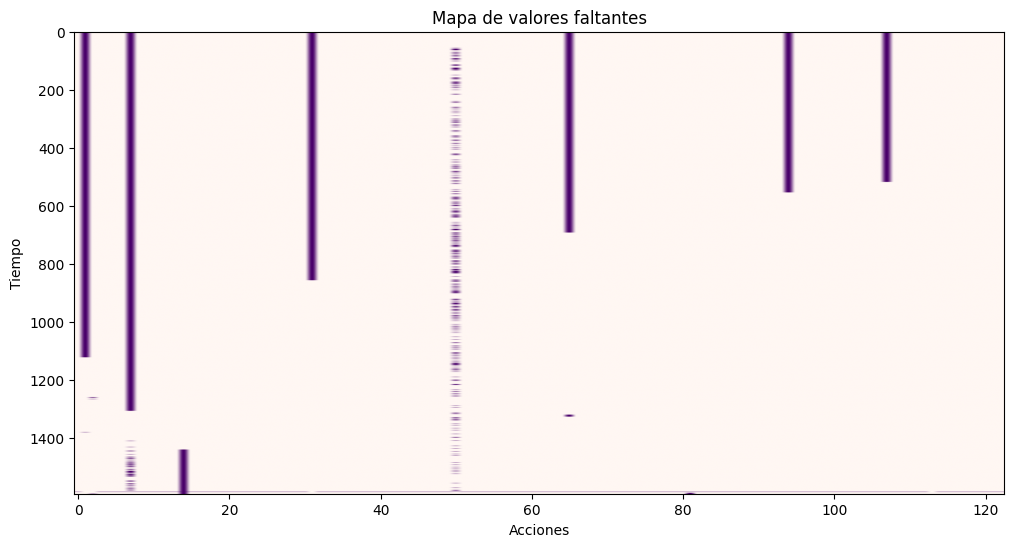

In [12]:
plt.figure(figsize=(12,6))
plt.imshow(precios.isna(), aspect='auto', cmap='RdPu')
plt.xlabel("Acciones")
plt.ylabel("Tiempo")
plt.title("Mapa de valores faltantes")
plt.show()

In [13]:
# nos quedamos con el rango de fechas con menor nulos
menos_nulos_data = precios.dropna()

print("Periodo común:", menos_nulos_data.index.min(), "->", menos_nulos_data.index.max())

Periodo común: 2025-03-11 00:00:00 -> 2025-09-18 00:00:00


Filas totales en el rango: 133
Filas completas en el rango: 104


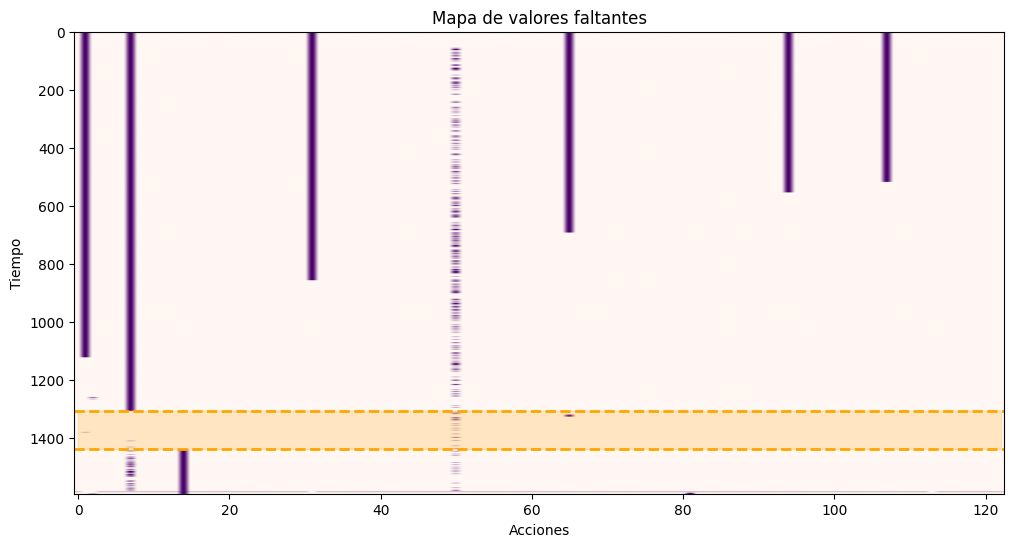

In [14]:
periodo_inicio = "2025-03-11"
periodo_fin = "2025-09-18"

ventana_comun = precios.loc[periodo_inicio:periodo_fin].copy()
print("Filas totales en el rango:", len(ventana_comun))
print("Filas completas en el rango:", len(ventana_comun.dropna()))

inicio_pos = precios.index.get_loc(periodo_inicio)
fin_pos = precios.index.get_loc(periodo_fin)


plt.figure(figsize=(12,6))
plt.plot()
plt.imshow(precios.isna(), aspect='auto', cmap='RdPu')
plt.axhline(y=inicio_pos, color='orange', linestyle='--', linewidth=2, label="Inicio Periodo Común")
plt.axhline(y=fin_pos, color='orange', linestyle='--', linewidth=2, label="Fin Periodo Común")
plt.fill_between([0, precios.shape[1]-1], inicio_pos, fin_pos, color='orange', alpha=0.2)
plt.xlabel("Acciones")
plt.ylabel("Tiempo")
plt.title("Mapa de valores faltantes")
plt.show()

2025-03-19 -> [('ACTINVRB.MX', 'ACTINVRB.MX')]
2025-03-25 -> [('ACTINVRB.MX', 'ACTINVRB.MX')]
2025-03-26 -> [('ACTINVRB.MX', 'ACTINVRB.MX')]
2025-03-31 -> [('LASITE.MX', 'LASITE.MX')]
2025-04-01 -> [('LASITE.MX', 'LASITE.MX')]
2025-04-02 -> [('LASITE.MX', 'LASITE.MX')]
2025-04-03 -> [('LASITE.MX', 'LASITE.MX')]
2025-04-04 -> [('LASITE.MX', 'LASITE.MX')]
2025-04-07 -> [('LASITE.MX', 'LASITE.MX')]
2025-04-08 -> [('LASITE.MX', 'LASITE.MX')]


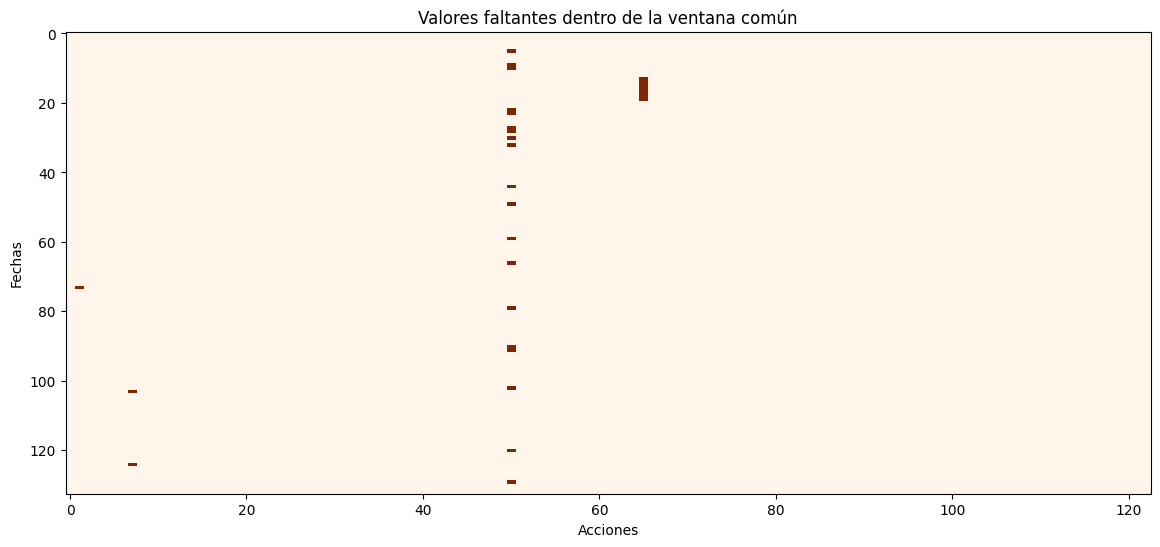

In [15]:
# Aun hay casos con fechas nan
fechas_con_nan = ventana_comun.index[ventana_comun.isna().any(axis=1)]
for fecha in fechas_con_nan[:10]:
    faltantes = ventana_comun.columns[ventana_comun.loc[fecha].isna()]
    print(f"{fecha.date()} -> {list(faltantes)}")

plt.figure(figsize=(14,6))
plt.imshow(ventana_comun.isna(), aspect='auto', cmap='Oranges')
plt.xlabel("Acciones")
plt.ylabel("Fechas")
plt.title("Valores faltantes dentro de la ventana común")
plt.show()

### **Tratamiento de Datos Faltantes**

In [16]:
## 1. Eliminamos las acciones que tienen mas del 10% faltantes

# Siempre trabajamos con una copia :)
conjunto_temporal_ventana_comun = ventana_comun.copy()
faltantes_p = conjunto_temporal_ventana_comun.isna().mean()
columnas_a_eliminar = faltantes_p[faltantes_p > 0.10].index.tolist()

print("Columnas eliminadas (>10% faltantes):")
print(columnas_a_eliminar)

conjunto_temporal_ventana_comun = conjunto_temporal_ventana_comun.drop(columns=columnas_a_eliminar)

print("Shape después de eliminar columnas:", conjunto_temporal_ventana_comun.shape)

Columnas eliminadas (>10% faltantes):
[('ACTINVRB.MX', 'ACTINVRB.MX')]
Shape después de eliminar columnas: (133, 122)


In [17]:
## 2. Imputamos faltantes restantes

def encontrar_nans_bloques(series):
  """encontrar_nans
  Funcion auxiliar que regresa una lista de tuplas:
     (inicio_idx, fun_idx, nan_tamanio)
  para cada bloque consecutivo de NaN en una serie.
  ---
  param:
    - series: serie de pandas
  ---
  return:
    - nan_bloque: lista de bloques con NaN
  """
  is_nan = series.isna().values
  nan_bloque = [] # lista de tuplas
  n = len(series)
  i = 0

  while i < n:
    if is_nan[i]:
      inicio = i
      while i < n and is_nan[i]:
        i += 1
      fin = i - 1
      nan_bloque.append((inicio, fin, fin - inicio + 1))
    else:
      i += 1

  return nan_bloque

**Caso 1:** Rachas cortas (≤ 3 valores consecutivos) usamos el promedio de los últimos 5 valores observados anteriores.

In [18]:
def imputar_corto(series, inicio, fin, ventana=5):
  """imputar_corto
  Funcion que imputa valores en un rango especifico de una serie utilizando la
  media movil de una ventana de observacion previa de forma iterativa.
  ---
  param:
    - series: serie de pandas (entrada original)
    - inicio: indice entero donde comienza el bloque a imputar
    - fin: indice entero donde termina el bloque a imputar
    - ventana: tamanio de la ventana de tiempo hacia atras para calcular la media
  ---
  return:
    - s: serie imputada
  """
  s = series.copy()
  for idx in range(inicio, fin + 1):
    prev = s.iloc[max(0, idx-ventana):idx].dropna()
    if len(prev) > 0:
      s.iloc[idx] = prev.mean()
  return s

**Caso 2:** Rachas largas (> 3 valores consecutivos) utilizamos interpolación lineal entre el último valor observado antes del bloque y el primer valor observado después del bloque.

Esto permite:
- Mantener continuidad temporal
- Evitar valores constantes artificiales
- Preservar tendencias

**NOTA:** En caso de no existir un valor anterior o posterior, los valores se dejan como NaN.

In [19]:
def imputar_largo(series, inicio, fin):
  """imputar_largo
  Funcion que realiza una interpolacion lineal para rellenar un bloque de
  valores (nulos) utilizando los valores conocidos inmediatamente
  anteriores y posteriores al rango.
  ---
  param:
    - series: serie de pandas
    - inicio: indice entero donde comienza el bloque a rellenar
    - fin: indice entero donde termina el bloque a rellenar
  ---
  return:
    - s: serie imputada
  """
  s = series.copy()

  idx_previo = inicio - 1
  idx_siguiente = fin + 1

  if idx_previo >= 0 and idx_siguiente < len(s):
    val_previo = s.iloc[idx_previo]
    val_siguiente = s.iloc[idx_siguiente]

    if pd.notna(val_previo) and pd.notna(val_siguiente):
      tamanio_ventana = fin - inicio + 1

      for k, idx in enumerate(range(inicio, fin + 1), start=1):
        s.iloc[idx] = val_previo + (val_siguiente - val_previo) * (k / (tamanio_ventana + 1))
  return s

NaN antes: 10
NaN después: 0


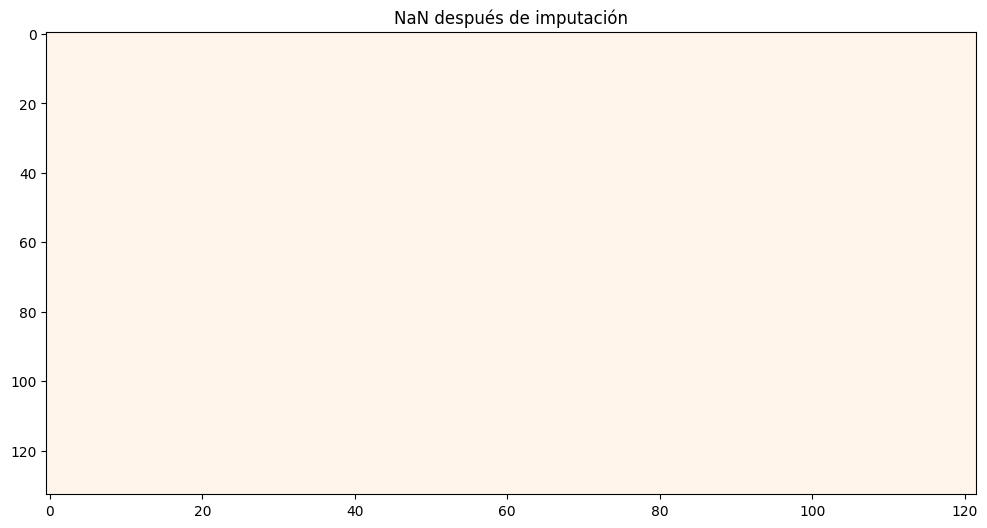

In [20]:
def imputar_serie(series):
  """imputar_serie
  Funcion que coordina la imputacion de una serie completa identificando
  bloques de valores faltantes y aplicando diferentes estrategias segun la
  longitud de cada bloque.
  ---
  param:
    - series: serie de pandas
  ---
  return:
    - s: serie completa
  """
  s = series.copy()
  runs = encontrar_nans_bloques(s)

  for start, end, length in runs:
    if length <= 3:
      s = imputar_corto(s, start, end)
    else:
      s = imputar_largo(s, start, end)

  return s

# Imputamos
conjunto_completo = conjunto_temporal_ventana_comun.copy()

for col in conjunto_completo.columns:
    conjunto_completo[col] = imputar_serie(conjunto_completo[col])

print("NaN antes:", conjunto_temporal_ventana_comun.isna().sum().sum())
print("NaN después:", conjunto_completo.isna().sum().sum())

# Visualizamos
plt.figure(figsize=(12,6))
plt.imshow(conjunto_completo.isna(), aspect='auto', cmap='Oranges')
plt.title("NaN después de imputación")
plt.show()

# Si ya sabemos que es complicado invertir nuestra matriz, ¿Qué podemos hacer entonces?



## **Enfoque 1:**

## Que no panda el cúnico: Dividamos para vencer

A primera instancia, es conveniente *descomponer* nuestra matriz en otras que sean más fáciles de invertir o calcular. Si recurrimos al álgebra lineal, a sabiendas que nuestra matriz de covarianzas es simétrica y definida positiva, podemos fragmentarla en una matriz ortogonal y una diagonal:

$$\Sigma = P\Lambda P^T$$

Los candidatos perfectos para estas matrices se construyen a partir de **Eigenvalores** y **Eigenvectores**

#### **Sin embargo, la matriz de en medio puede ser una matriz difícil de tratar e invertir**. Por ende, podemos hacer uso de técnicas que ya conocemos, como el Análisis de Componentes Principales

## ¿Y esto qué tiene que ver con la navidad?

Este método simplifica nuestro espacio: Nos permirte identificar que **no** nos sirve para nuestro análisis, y proyecta la información a direcciones que no se afectan entre sí. En el *argot financiero* se le conoce como **Corte espectral**. Entre sus ventajas no solo está el reducir la cantidad de información: También tiene peso la reducción de ruido y de costo computacional

> Con menos información y procesamiento, obtenemos un resultado similar ☝️

In [21]:
# Calculamos los rendimientos logaritmicos y su matriz de covarianza (Σ):

# 1. Rendimientos logaritmicos
rendimientos_log = np.log(conjunto_completo / conjunto_completo.shift(1)).dropna() # dropna para primer fecha

# 2. Media y Varianza DIARIA
mu_diario = rendimientos_log.mean()
sigma_diaria = rendimientos_log.cov()

# 3. Anualizamos
factor_anual = 252
mu_anual = mu_diario * factor_anual
sigma_anual = sigma_diaria * factor_anual

print("Rendimientos Logarítmicos Esperados (Anualizados):")
display(mu_anual.head())

Rendimientos Logarítmicos Esperados (Anualizados):


,,0
,Ticker,
AC.MX,AC.MX,-0.136482
AGUILASCPO.MX,AGUILASCPO.MX,0.655066
ALTERNA.MX,ALTERNA.MX,0.102100
ASURB.MX,ASURB.MX,0.496164
BBVA.MX,BBVA.MX,0.406050


In [22]:
print("\nMatriz de Covarianza Logarítmica (Anualizada):")
display(sigma_anual.head())


Matriz de Covarianza Logarítmica (Anualizada):


,,AC.MX,AGUILASCPO.MX,ALTERNA.MX,ASURB.MX,BBVA.MX,CADUA.MX,CMOCTEZ.MX,DIABLOSO.MX,FINDEP.MX,GBMO.MX,...,LACOMERUBC.MX,MEDICAB.MX,OMAB.MX,POCHTECB.MX,Q.MX,RLHA.MX,SORIANAB.MX,TMMA.MX,VASCONI.MX,VOLARA.MX
,Ticker,AC.MX,AGUILASCPO.MX,ALTERNA.MX,ASURB.MX,BBVA.MX,CADUA.MX,CMOCTEZ.MX,DIABLOSO.MX,FINDEP.MX,GBMO.MX,...,LACOMERUBC.MX,MEDICAB.MX,OMAB.MX,POCHTECB.MX,Q.MX,RLHA.MX,SORIANAB.MX,TMMA.MX,VASCONI.MX,VOLARA.MX
,Ticker,,,,,,,,,,,,,,,,,,,,,
AC.MX,AC.MX,0.063010,0.002295,0.000050,0.018659,0.011285,-0.004408,0.004187,0.004343,-0.003078,0.004184,...,0.011494,-0.005288,0.011288,-0.006504,0.018168,0.004396,0.011799,-0.006995,0.003911,0.017253
AGUILASCPO.MX,AGUILASCPO.MX,0.002295,0.053405,-0.000041,0.001854,-0.004611,0.002318,0.000944,0.000304,0.028468,-0.009337,...,-0.007209,-0.001326,-0.002706,-0.004867,-0.001759,0.004629,-0.005499,0.002011,-0.000019,0.002321
ALTERNA.MX,ALTERNA.MX,0.000050,-0.000041,0.000099,-0.000043,-0.000285,0.000009,-0.000224,0.000004,-0.000617,-0.000190,...,-0.000249,-0.000157,-0.000195,-0.000261,-0.000295,-0.000235,0.000040,0.000118,-0.000035,-0.000628
ASURB.MX,ASURB.MX,0.018659,0.001854,-0.000043,0.074841,0.007877,-0.016725,0.011155,0.008678,-0.015916,-0.002281,...,0.016494,0.006363,0.047488,-0.004149,0.026310,-0.009299,0.005124,0.001217,0.007146,0.037361
BBVA.MX,BBVA.MX,0.011285,-0.004611,-0.000285,0.007877,0.110262,0.002169,-0.000962,0.004875,0.010512,0.000710,...,0.008568,0.011184,-0.002511,-0.002839,0.001426,-0.011758,0.010527,0.002185,0.011720,0.011553


In [23]:
# Descomposicion en valores propios de la matriz de covarianza
eigenvalues, eigenvectors = np.linalg.eigh(sigma_anual)

# Ordenamos de mayor a menor
idx = np.argsort(eigenvalues)[::-1]
eigenvalues  = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

print("Eigenvalores ordenados: ",eigenvalues[:4])

Eigenvalores ordenados:  [1.32145555 1.20972869 0.67553177 0.59374137]


Componentes necesarios para explicar ≥ 90% de varianza: k = 41
Varianza explicada con 41 componentes: 90.41%


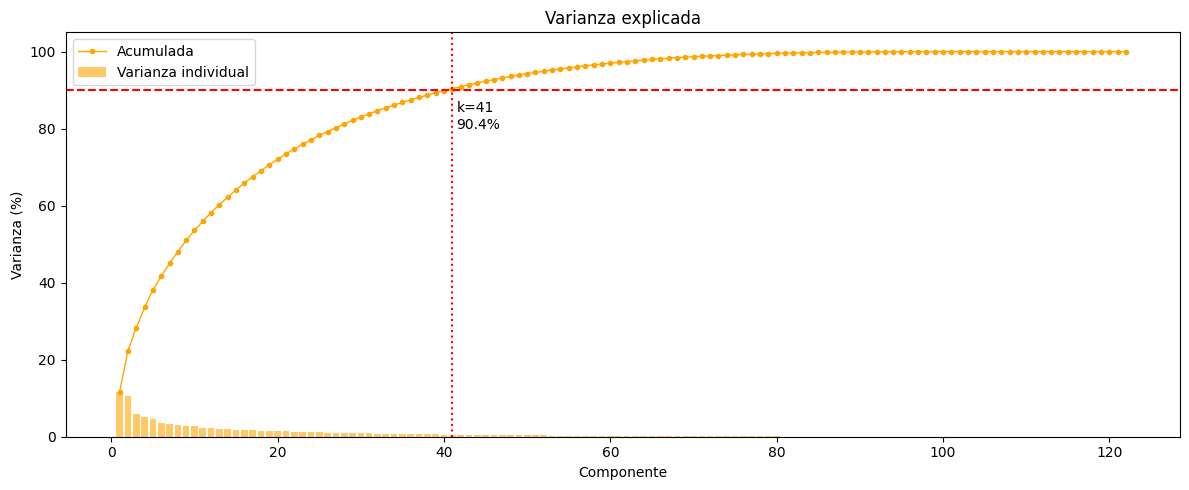

In [24]:
varianza_explicada = eigenvalues / np.sum(eigenvalues)
varianza_acumulada = np.cumsum(varianza_explicada)

UMBRAL = 0.90 # Podemos cambiarlo :)
k_90 = np.argmax(varianza_acumulada >= UMBRAL) + 1
print(f"Componentes necesarios para explicar ≥ {UMBRAL*100:.0f}% de varianza: k = {k_90}")
print(f"Varianza explicada con {k_90} componentes: {varianza_acumulada[k_90-1]*100:.2f}%")

x = np.arange(1, len(eigenvalues) + 1)

plt.figure(figsize=(12, 5))
plt.bar(x, varianza_explicada * 100, alpha=0.6, label='Varianza individual', color = 'orange')
plt.plot(x, varianza_acumulada * 100, marker='o', linewidth=1, label='Acumulada', markersize=3, color='orange')
plt.axhline(90, linestyle='--', color='r')
plt.axvline(k_90, linestyle=':',color='r')
plt.text(k_90 + 0.5, 80, f"k={k_90}\n{varianza_acumulada[k_90-1]*100:.1f}%", fontsize=10)
plt.xlabel('Componente')
plt.ylabel('Varianza (%)')
plt.title('Varianza explicada')
plt.legend()
plt.ylim(0, 105)
plt.tight_layout()
plt.show()

k = k_90
eigenvalues_k = eigenvalues[:k]
eigenvectors_k = eigenvectors[:, :k]

#### **Se necesitan de muchas componentes para explicar gran parte de la varianza**

In [25]:
# La covarianza de los rendimientos en el nuevo espacio (Z) debe ser una matriz diagonal
rendimientos_pca = rendimientos_log.values @ eigenvectors
cov_pca = np.cov(rendimientos_pca, rowvar=False) * factor_anual

# Elementos fuera de la diagonal principal son casi cero
print("Matriz de Covarianza de Eigenportafolios (Diagonal):")
display(np.round(cov_pca, 4))

Matriz de Covarianza de Eigenportafolios (Diagonal):


array([[ 1.3215, -0.    , -0.    , ..., -0.    , -0.    ,  0.    ],
       [-0.    ,  1.2097, -0.    , ..., -0.    ,  0.    ,  0.    ],
       [-0.    , -0.    ,  0.6755, ...,  0.    ,  0.    ,  0.    ],
       ...,
       [-0.    , -0.    ,  0.    , ...,  0.    , -0.    , -0.    ],
       [-0.    ,  0.    ,  0.    , ..., -0.    ,  0.    ,  0.    ],
       [ 0.    ,  0.    ,  0.    , ..., -0.    ,  0.    ,  0.    ]])

# Forma genérica de un modelo de optimización
### Forma Genérica del Modelo de Optimización

Para estandarizar la resolución del problema y evitar redundancias computacionales, se define un motor de optimización genérico. La estructura matemática base se mantiene constante, permitiendo intercambiar únicamente la función objetivo que calcula el riesgo.

El problema general se define como:

$$
\begin{aligned}
\min_{x \in \mathbb{R}^n} \quad & f_{\text{riesgo}}(x) \\
\text{sujeto a:} \quad & \mu^T x \ge \mu_P \\
& \sum_{i=1}^n x_i = 1 \\
& x_i \ge 0 \quad \forall i=1,\dots,n
\end{aligned}
$$


`
    def optimizador_generico(rendimientos_esperados, rendimiento_minimo, funcion_riesgo_elegida):`
    
      # 1. Identificamos la cantidad de activos en el mercado
      n_activos = len(rendimientos_esperados)
    
      # 2. Definimos las Reglas Invariables (Restricciones)
      def restriccion_presupuesto(pesos):
          # Todo el capital (1.0 o 100%) debe estar invertido
          return sum(pesos) == 1.0
        
      def restriccion_rendimiento(pesos):
          # El rendimiento esperado debe superar la meta exigida
          return producto_punto(rendimientos_esperados, pesos) >=   rendimiento_minimo
        
      restricciones_mercado = [restriccion_presupuesto,   restriccion_rendimiento]
    
      # 3. Definimos las Políticas del Inversor (Límites)
      # Prohibimos ventas en corto: nadie invierte dinero negativo
      limites_inversion = [(0, infinito) for activo in range  (n_activos)]
    
      # 4. Establecemos un punto de partida neutral
      # (Empezamos dividiendo el dinero a partes iguales)
      pesos_iniciales = [1.0 / n_activos] * n_activos
    
      # 5. Ejecutamos el motor de resolución
      solucion = minimizar(
          funcion_objetivo = funcion_riesgo_elegida,  # <--- Aquí inyectamos el Modelo 4, 6
          punto_inicio = pesos_iniciales,
          limites = limites_inversion,
          restricciones = restricciones_mercado
      )
    
      return solucion.pesos_optimos, solucion.riesgo_minimo_alcanzado`

## **¿Cómo funciona minimize?** ☝️☝️☝️

#### Análisis de los parámetros de la función minimize de SciPy:


* fun (Función Objetivo): Es la función matemática que el algoritmo intentará minimizar. En nuestro caso, recibe los pesos del portafolio y devuelve el riesgo calculado.
    
* x0 (Punto Inicial): Un arreglo de valores iniciales para las variables. Es el punto de partida del algoritmo. Usualmente iniciamos asignando un peso igual a todos los activos.
    
* args (Argumentos Extra): Una tupla opcional de datos adicionales que la función objetivo (fun) y sus derivadas necesiten para funcionar, como la matriz de covarianza o el vector de rendimientos.
    
* method (Método): El motor o algoritmo matemático específico a usar para buscar el mínimo. Nosotros utilizamos 'SLSQP' porque maneja excelentemente funciones cuadráticas con múltiples restricciones y límites simultáneos.
        
* bounds (Límites): Fronteras directas para cada variable. Aquí es donde definimos el intervalo para impedir matemáticamente que el algoritmo asigne pesos negativos, bloqueando las ventas en corto.
    
* constraints (Restricciones): Diccionarios que definen relaciones que las variables deben cumplir. Permite definir igualdades y desigualdades.

#### SLSQP

SLSQP (Sequential Least SQuares Programming) minimiza funciones construyendo aproximaciones cuadráticas locales de la función objetivo. Es ideal para optimización en finanzas porque maneja simultáneamente múltiples restricciones de igualdad (ej. suma de pesos igual a 1) y desigualdad (ej. rendimiento esperado), respetando los límites de cada variable (ej. sin ventas en corto). Al ser "secuencial", actualiza su estimación iterativamente hasta encontrar el mínimo global dentro de las fronteras permitidas.
    


# **Modelo 4**


$$V_I^* = \quad \min \quad \sum_{i \in I} \lambda_i z_i^2$$
$$\text{s.a.} \quad  z_i = P_i^{\mathrm{T}}\mathbf{x}, \quad i \in I$$
$$\mu^{\mathrm{T}}\mathbf{x} \ge \mu_P$$
$$\mathbf{x} \in \mathcal{S}.$$


In [26]:
def modelo_4(mu, mu_P, eigenvalores, eigenvectores, I):
    """
    Función que encuentra el portafolio de minima varianza utilizando el Modelo 4.
    Este modelo solo considera el riesgo explicado por los primeros 'I'
    componentes principales.
    ---
    params:
      - mu: Array con los rendimientos esperados de los activos individuales.
      - mu_P: Rendimiento objetivo mínimo requerido para el portafolio.
      - eigenvalores: Vector con los autovalores de la matriz de covarianza, ordenados de mayor a menor.
      - eigenvectores: Matriz donde cada columna es un autovector correspondiente a los autovalores.
      - I: Cantidad de componentes principales a utilizar para la aproximacion.
    ---
    return:
      - Vector de pesos optimos del portafolio (x*).
      - Valor de la varianza minima aproximada alcanzada (V_I^*).
    """
    n = len(mu)

    def objetivo(x):
        lambda_I = eigenvalores[:I]
        P_I = eigenvectores[:, :I]
        z_I = P_I.T @ x
        return np.sum(lambda_I * (z_I ** 2))

    restricciones = [{'type': 'ineq', 'fun': lambda x: (mu.T @ x) - mu_P},
                     {'type': 'eq', 'fun': lambda x: np.sum(x) - 1.0}]

    limites = [(None, None) for _ in range(n)] # Ventas en corto
    x0 = np.ones(n) / n

    resultado = minimize(objetivo, x0, method='SLSQP', bounds=limites, constraints=restricciones)
    return resultado.x, resultado.fun

In [27]:
mu_P = 0.10 # Este rendimiento esperado lo elegimos nosotros
mu_array = mu_anual.values
sigma_array = sigma_anual.values

def objetivo_original(x):
    """
    Funcion original de la varianza a minimizar.
    """
    return x.T @ sigma_array @ x


def restriccion_rendimiento_orig(x):
    """
    Restriccion para que el rendimiento minimo sea mu_p
    """
    return (mu_array.T @ x) - mu_P


def restriccion_presupuesto_orig(x):
    """
    Ponderaciones deben sumar 1.
    """
    return np.sum(x) - 1.0


restricciones_orig = [
    {'type': 'ineq', 'fun': restriccion_rendimiento_orig},
    {'type': 'eq', 'fun': restriccion_presupuesto_orig}]

limites_orig = [(None, None) for _ in range(len(mu_array))] # Ventas en corto
x0_orig = np.ones(len(mu_array)) / len(mu_array) # Punto inicial para el minimize

resultado_orig = minimize(
    objetivo_original, x0_orig, method='SLSQP',
    bounds=limites_orig, constraints=restricciones_orig)

V_optimo = resultado_orig.fun
pesos_optimos_orig = resultado_orig.x

pesos_optimos_aprox, V_I_optimo = modelo_4(
    mu=mu_array, mu_P=mu_P,
    eigenvalores=eigenvalues, eigenvectores=eigenvectors,
    I=k_90,)

limite_inferior = V_I_optimo
limite_superior = objetivo_original(pesos_optimos_aprox)

lambda_descartados = eigenvalues[k_90:]
P_descartados = eigenvectors[:, k_90:]
z_descartados = P_descartados.T @ pesos_optimos_aprox
error_teorico = np.sum(lambda_descartados * (z_descartados ** 2))

print("\n--- RESULTADOS DE LA OPTIMIZACIÓN USANDO MINIMIZE ---")
print(f"Rendimiento Objetivo (mu_P):              {mu_P*100:.1f}%")
print(f"Componentes Utilizados (k):               {k_90}")
print("-" * 50)
print(f"Mínima Varianza Real (V*):                  {V_optimo:.6f}")
print(f"Varianza Aproximada(V_I*) [Cota Inferior]: {limite_inferior:.6f}")
print(f"Varianza Real Aproximada  [Cota Superior]: {limite_superior:.6f}")
print("\n")
print("Teoría: V_I* <= V* <= Varianza Real Aproximada")
print(f"Práctica: {limite_inferior:.6f} <= {V_optimo:.6f} <= {limite_superior:.6f}")
print("-" * 50)
print(f"Error teórico:                                     {error_teorico:.8f}")
print(f"Diferencia real (Cota Superior - Cota Inferior):   {limite_superior - limite_inferior:.8f}")



--- RESULTADOS DE LA OPTIMIZACIÓN USANDO MINIMIZE ---
Rendimiento Objetivo (mu_P):              10.0%
Componentes Utilizados (k):               41
--------------------------------------------------
Mínima Varianza Real (V*):                  0.000028
Varianza Aproximada(V_I*) [Cota Inferior]: 0.000001
Varianza Real Aproximada  [Cota Superior]: 0.000205


Teoría: V_I* <= V* <= Varianza Real Aproximada
Práctica: 0.000001 <= 0.000028 <= 0.000205
--------------------------------------------------
Error teórico:                                     0.00020391
Diferencia real (Cota Superior - Cota Inferior):   0.00020391


##### *¡Sí nos estan acotando a la mínima varianza!*

In [28]:
# Visualizacion de la convergencia de cotas aproximadas
n_total_acciones = len(mu_array)
rango_componentes = range(1, n_total_acciones + 1)

cotas_inferiores = []
cotas_superiores = []

for i in rango_componentes:
  #'i' componentes
  pesos_aprox, v_i_star = modelo_4(mu=mu_array,
                                   mu_P=mu_P,
                                   eigenvalores=eigenvalues,
                                   eigenvectores=eigenvectors,
                                   I=i)

  # Cota Inferior (V_I*)
  cotas_inferiores.append(v_i_star)

  # Cota Superior
  varianza_real_evaluada = pesos_aprox.T @ sigma_array @ pesos_aprox
  cotas_superiores.append(varianza_real_evaluada)

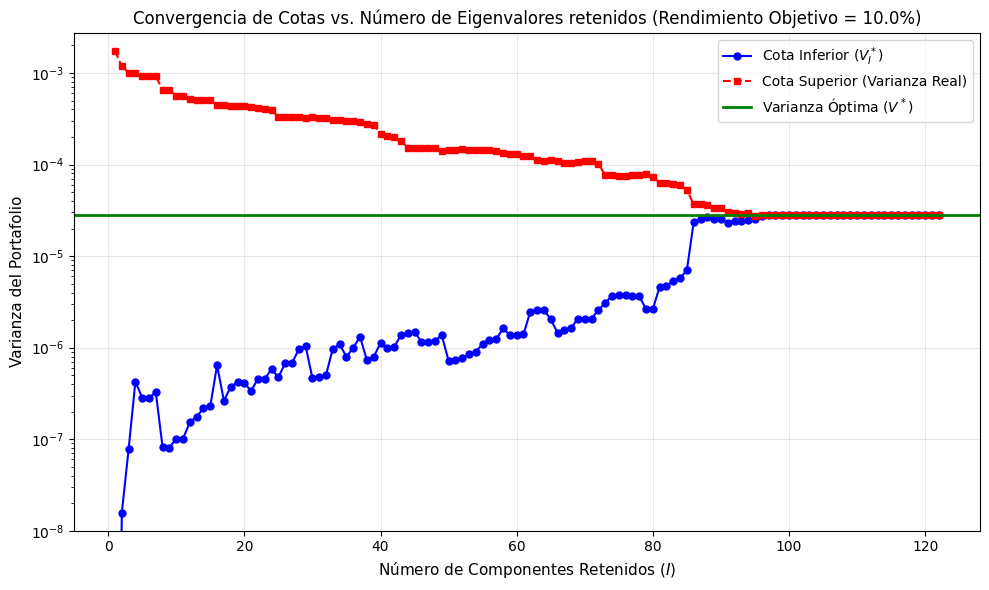

Cota máxima: 0.0017501714330246526


In [29]:
plt.figure(figsize=(10, 6))
plt.plot(rango_componentes, cotas_inferiores, 'b-o', label='Cota Inferior ($V_I^*$)', markersize=5)
plt.plot(rango_componentes, cotas_superiores, 'r--s', label='Cota Superior (Varianza Real)', markersize=5)
plt.axhline(y=V_optimo, color='g', linestyle='-', linewidth=2, label='Varianza Óptima ($V^*$)')
plt.title(f'Convergencia de Cotas vs. Número de Eigenvalores retenidos (Rendimiento Objetivo = {mu_P*100:.1f}%)', fontsize=12)
plt.xlabel('Número de Componentes Retenidos ($I$)', fontsize=11)
plt.ylabel('Varianza del Portafolio', fontsize=11)
plt.legend(loc='best')
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.ylim([1e-8, 0.0027500763538707378])
plt.tight_layout()
plt.show()

print("Cota máxima:", max(cotas_superiores))

#### **Se logra acotar y converger a la varianza óptima buscada.**

## **Error**

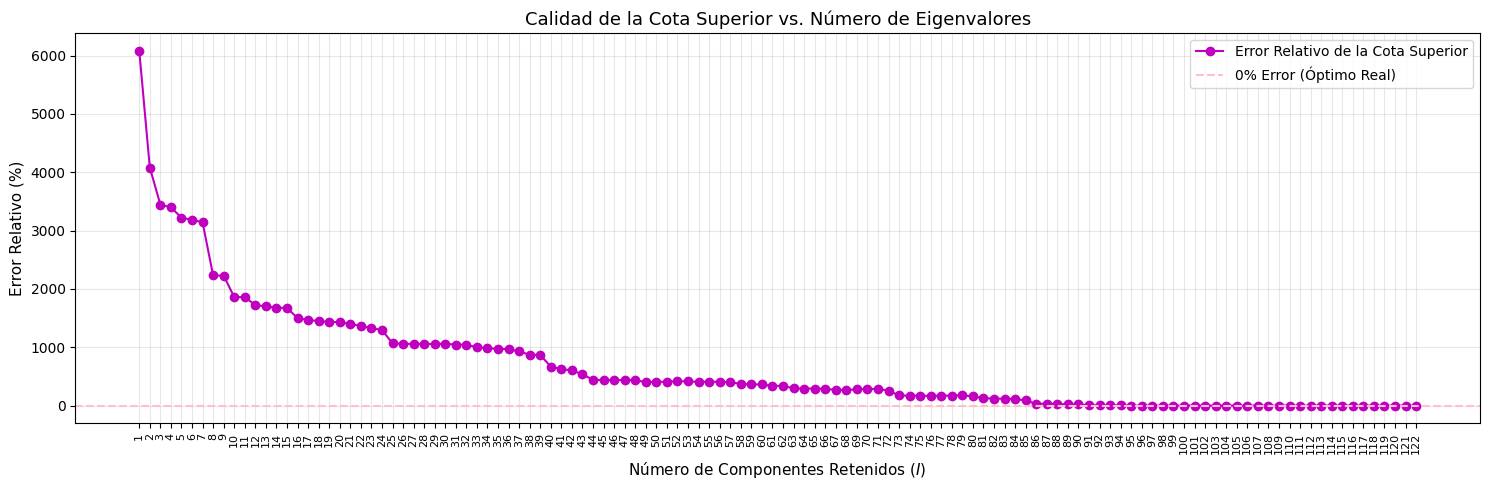

Error máximo usando 1 componente: 6085.17%
Error usando 41 componentes: 624.07728%


In [30]:
# Calidad de la cota superior
# Formula: [(Cota superior - Rendimiento optimo real) / Riesgo optimo real] * 100

calidad_cota_superior = [((cota_sup - V_optimo) / V_optimo) * 100 for cota_sup in cotas_superiores]
plt.figure(figsize=(15, 5))
plt.plot(rango_componentes, calidad_cota_superior, 'm-o', label='Error Relativo de la Cota Superior', markersize=6)
plt.axhline(0, color='pink', linestyle='--', linewidth=1.5, label='0% Error (Óptimo Real)')
plt.title('Calidad de la Cota Superior vs. Número de Eigenvalores', fontsize=13)
plt.xlabel('Número de Componentes Retenidos ($I$)', fontsize=11)
plt.ylabel('Error Relativo (%)', fontsize=11)
plt.xticks(rango_componentes, rotation=90, fontsize=8)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Error máximo usando 1 componente: {calidad_cota_superior[0]:.2f}%")
n = 41 # ELIGAN UNO (0,122]
print(f"Error usando {n} componentes: {calidad_cota_superior[n-1]:.5f}%")

Entre mayor sea el número de componentes, menor será el error. Aunque, en general, tratamos con errores muy grandes.

In [31]:
# Considerando los 41 componentes tenemos el siguiente error:

# mayor autovalor NO utilizado
lambda_max_no_usado = eigenvalues[k_90]

# Norma cuadrada de los pesos aproximados ||x_I*||^2
norma_x_cuadrada = np.sum(pesos_optimos_aprox**2)

# epsilon = el limite teorico del error relativo
epsilon_teorico = (lambda_max_no_usado * norma_x_cuadrada) / V_I_optimo

error_relativo_real = ((limite_superior - V_optimo) / V_optimo )*100

print(f"Epsilon (Cota teórica de error): {epsilon_teorico:.6f}%")
print(f"Error relativo real:             {error_relativo_real:.6f}%")

Epsilon (Cota teórica de error): 1204.989127%
Error relativo real:             624.077283%


#### **¡Podemos acotar a nuestro error relativo!**

## Frontera Eficiente

In [32]:
rango_mu_P = np.linspace(mu_array.min(), mu_array.max(), 50)

v_star_exacto = []
v_n_inferior = []
v_n_hat_superior = []
mu_p_grafica = []

for mu_target in rango_mu_P:
    restricciones_target = [
        {'type': 'ineq', 'fun': lambda x, r=mu_target: (mu_array.T @ x) - r},
        {'type': 'eq', 'fun': lambda x: np.sum(x) - 1.0},
    ]
    res_exacto = minimize(
        objetivo_original, x0_orig, method='SLSQP',
        bounds=limites_orig, constraints=restricciones_target,
    )
    pesos_aprox, v_n_star = modelo_4(
        mu=mu_array, mu_P=mu_target,
        eigenvalores=eigenvalues, eigenvectores=eigenvectors, I=k_90,
    )
    v_n_hat = pesos_aprox.T @ sigma_array @ pesos_aprox

    if res_exacto.success:
        v_star_exacto.append(res_exacto.fun)
        v_n_inferior.append(v_n_star)
        v_n_hat_superior.append(v_n_hat)
        mu_p_grafica.append(mu_target)

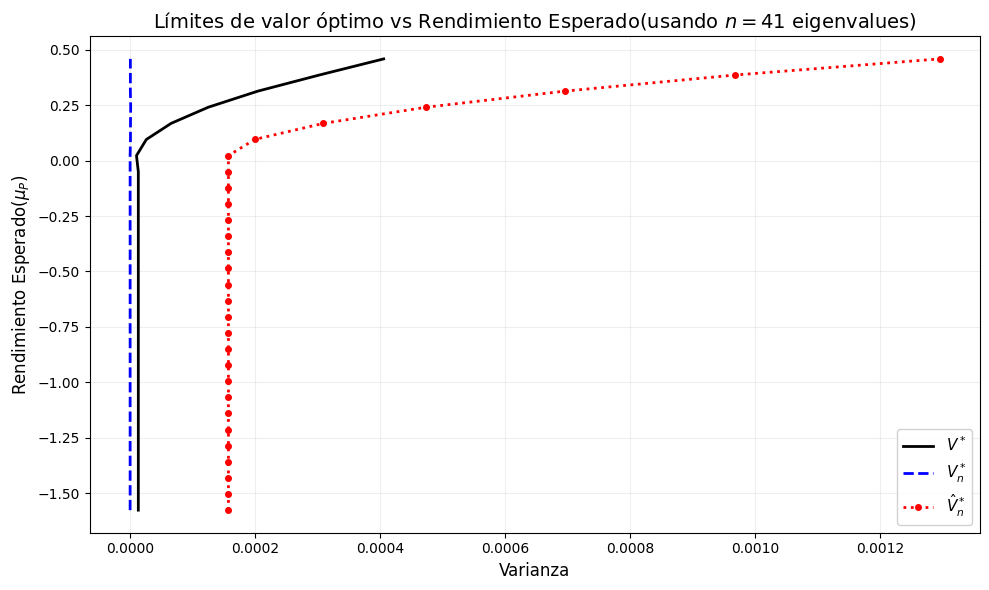

In [33]:
plt.figure(figsize=(10, 6))
plt.plot( v_star_exacto, mu_p_grafica, 'k-', linewidth=2, label='$V^*$')
plt.plot( v_n_inferior, mu_p_grafica, 'b--', linewidth=2, label='$V^*_n$')
plt.plot( v_n_hat_superior, mu_p_grafica, 'r:', linewidth=2, marker='o', markersize=4, label=r'$\hat{V}^*_n$')
plt.title(f'Límites de valor óptimo vs Rendimiento Esperado(usando $n={k_90}$ eigenvalues)', fontsize=14)
plt.ylabel(r'Rendimiento Esperado($\mu_P$)', fontsize=12)
plt.xlabel('Varianza', fontsize=12)
plt.legend(loc='lower right', fontsize=11, framealpha=0.9)
plt.grid(True, linestyle='-', alpha=0.2)
plt.tight_layout()
plt.show()

Las cotas se siguen cumpliendo al graficar la frontera eficiente. :)

In [34]:
# ponderaciones equitativas
n_activos = len(mu_array)
x_0 = np.ones(n_activos) / n_activos
#print(x_0)

In [35]:
# Obtenemos los datos del IPC para el periodo que usamos
data_index = yf.download("^MXX", start=inicio, auto_adjust=True, progress=False)["Close"]
ren_index = np.log(data_index / data_index.shift(1)).dropna()
mu_index = float(ren_index.mean().iloc[0]) * 252
var_index = float(ren_index.var().iloc[0]) * 252
std_index = np.sqrt(var_index)

print(f"Rendimiento IPC: {mu_index:.4f}, Varianza IPC: {var_index:.6f}")


Rendimiento IPC: 0.0657, Varianza IPC: 0.030212


In [36]:
# USANDO LO VISTO CON ENRIQUE

def frontera_eficiente_sin_restricciones(mu, Sigma, n_points=200, delta=1e-6):
    """
    Frontera eficiente (permite cortos).
    Fórmula clásica con:
      A = 1' Σ^{-1} 1
      B = 1' Σ^{-1} μ
      C = μ' Σ^{-1} μ
      D = AC - B^2
    Varianza mínima para un retorno objetivo r:
      σ^2(r) = (A r^2 - 2B r + C) / D
    """
    n    = len(mu)
    ones = np.ones(n)
    invS = np.linalg.inv(Sigma + delta * np.eye(n))   # ridge mínimo

    A = ones @ invS @ ones
    B = ones @ invS @ mu
    C = mu   @ invS @ mu
    D = A * C - B**2

    r_grid = np.linspace(mu.min() * 0.8, mu.max() * 1.2, n_points)
    sigma2 = np.maximum((A * r_grid**2 - 2 * B * r_grid + C) / D, 0)
    sigma  = np.sqrt(sigma2)

    r_gmv     = B / A
    sigma_gmv = np.sqrt(1 / A)
    mask_eff  = r_grid >= r_gmv

    # devuelve: rama eficiente, curva completa, GMVP
    return sigma[mask_eff], r_grid[mask_eff], sigma, r_grid, r_gmv, sigma_gmv

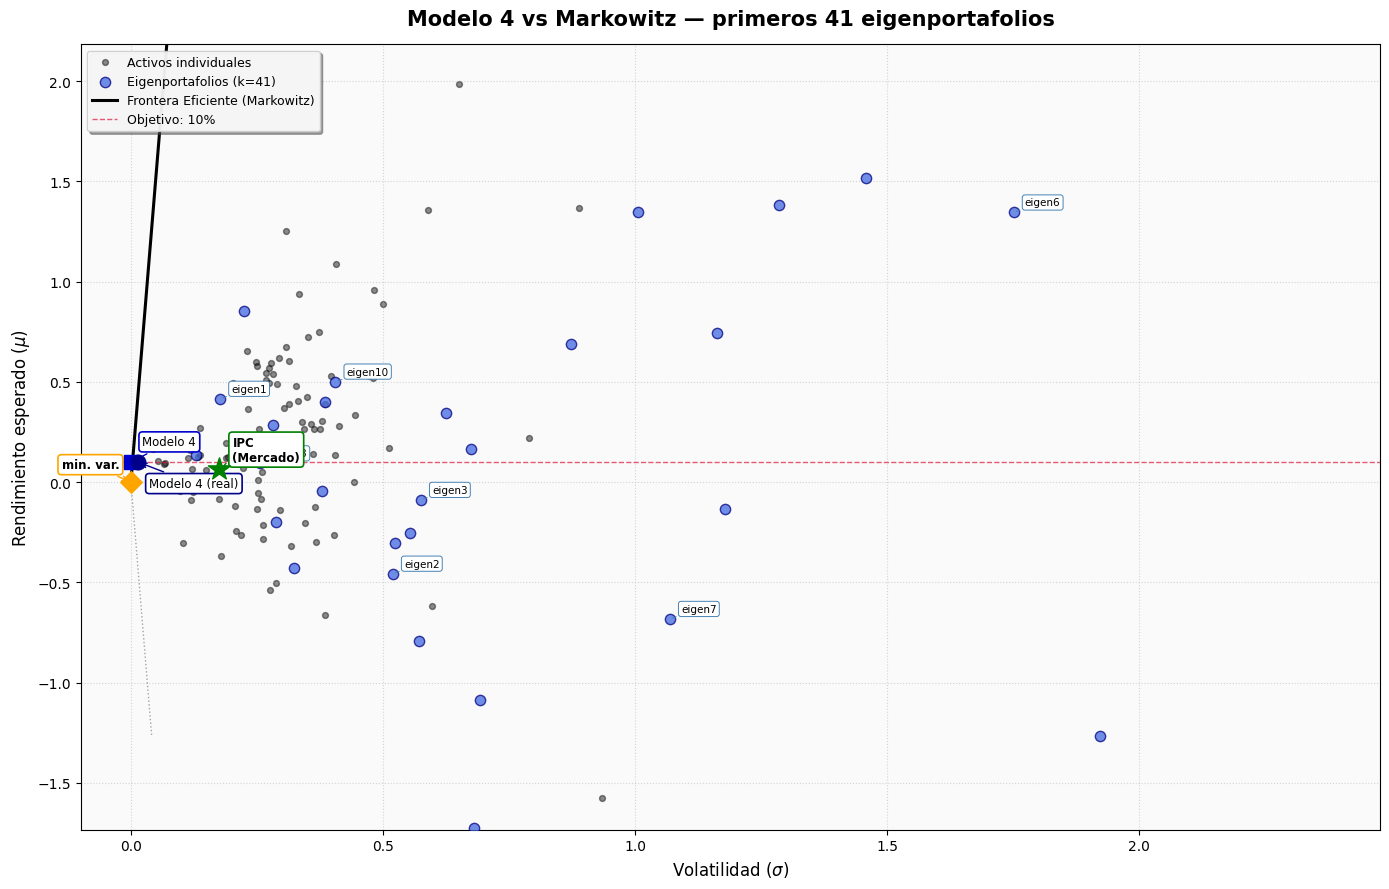

In [37]:
k = k_90  # primeros 41 eigenvectores

sumas = eigenvectors[:, :k].sum(axis=0)          # 1'e_i para cada i
Z     = eigenvectors[:, :k] / sumas[np.newaxis, :]  # pesos que suman 1

ren_eigen = Z.T @ mu_array                        # rendimiento de cada eigenportafolio
var_eigen = np.array([Z[:, i].T @ sigma_array @ Z[:, i] for i in range(k)])
std_eigen = np.sqrt(var_eigen)


# Frontera Eficiente
sigma_eff, r_eff, sigma_full, r_full, r_gmv, vol_gmvp = \
    frontera_eficiente_sin_restricciones(mu=mu_array, Sigma=sigma_array,
                                         n_points=300)
# GMVP
ren_gmvp = r_gmv
std_gmvp = vol_gmvp


# Modelo 4
x_opt_m4, var_est_m4 = modelo_4(mu=mu_array, mu_P=0.10,
                                  eigenvalores=eigenvalues,
                                  eigenvectores=eigenvectors,
                                  I=k_90)
var_real_m4 = x_opt_m4.T @ sigma_array @ x_opt_m4
std_est_m4  = np.sqrt(var_est_m4)
std_real_m4 = np.sqrt(var_real_m4)


# Grafica
fig, ax = plt.subplots(figsize=(14, 9))
ax.set_facecolor('#fafafa')
ax.grid(True, linestyle=':', alpha=0.5)

# Activos individuales
std_activos = np.sqrt(np.diag(sigma_array))
ax.scatter(std_activos, mu_array,
           color='black', s=18, alpha=0.45, zorder=1, label='Activos individuales')

# Eigenportafolios
ax.scatter(std_eigen, ren_eigen,
           color='royalblue', s=55, marker='o', edgecolors='navy',
           alpha=0.75, zorder=3, label=f'Eigenportafolios (k={k})')

# Etiquetas de los primeros 10 eigenportafolios
for i in range(min(10, k)):
    ax.annotate(f'eigen{i+1}',
                xy=(std_eigen[i], ren_eigen[i]),
                xytext=(8, 5), textcoords='offset points',
                fontsize=7.5,
                bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='steelblue', lw=0.7),
                arrowprops=dict(arrowstyle='-', color='steelblue', lw=0.7))

# Frontera Eficiente
ax.plot(sigma_full, r_full,
        color='black', linewidth=1, linestyle=':', alpha=0.35, zorder=4)
ax.plot(sigma_eff, r_eff,
        color='black', linewidth=2.2, zorder=5, label='Frontera Eficiente (Markowitz)')


# Rendimiento objetivo
ax.axhline(y=0.10, color='crimson', linestyle='--',
           linewidth=1, alpha=0.7, label='Objetivo: 10%')

# IPC
ax.scatter(std_index, mu_index, color='green', marker='*', s=280, zorder=6)
ax.annotate('IPC\n(Mercado)', xy=(std_index, mu_index),
            xytext=(10, 6), textcoords='offset points', fontsize=8.5, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='green', lw=1.2),
            arrowprops=dict(arrowstyle='->', color='green', lw=1))

# GMVP
ax.scatter(std_gmvp, ren_gmvp, color='orange', marker='D', s=120, zorder=6)
ax.annotate('min. var.', xy=(std_gmvp, ren_gmvp),
            xytext=(-50, 10), textcoords='offset points', fontsize=8.5, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='orange', lw=1.2),
            arrowprops=dict(arrowstyle='->', color='orange', lw=1))

# Modelo 4 — riesgo estimado
ax.scatter(std_est_m4, 0.10, color='mediumblue', marker='s', s=110, zorder=6)
ax.annotate(r'Modelo 4', xy=(std_est_m4, 0.10),
            xytext=(8, 12), textcoords='offset points', fontsize=8.5,
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='mediumblue', lw=1.2),
            arrowprops=dict(arrowstyle='->', color='mediumblue', lw=1))

# Modelo 4 — riesgo real
ax.scatter(std_real_m4, 0.10, color='darkblue', marker='o', s=110, zorder=6)
ax.annotate(r'Modelo 4 (real)', xy=(std_real_m4, 0.10),
            xytext=(8, -18), textcoords='offset points', fontsize=8.5,
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='darkblue', lw=1.2),
            arrowprops=dict(arrowstyle='->', color='darkblue', lw=1))

ax.set_xlabel(r'Volatilidad ($\sigma$)', fontsize=12)
ax.set_ylabel(r'Rendimiento esperado ($\mu$)', fontsize=12)
ax.set_title(f'Modelo 4 vs Markowitz — primeros {k} eigenportafolios',
             fontsize=15, fontweight='bold', pad=14)
ax.legend(loc='upper left', fontsize=9, frameon=True, framealpha=0.9, shadow=True)
ax.grid(True, linestyle=':', alpha=0.5)

# Excluimos outliers extremos
p95_std = np.nanpercentile(np.concatenate([std_eigen, std_activos]), 95)
x_max   = max(p95_std, std_real_m4) * 1.3
margen  = x_max * 0.04
ax.set_xlim(-margen, max(p95_std, std_real_m4) * 1.3)
ax.set_ylim(mu_array.min() * 1.1, mu_array.max() * 1.1)

plt.tight_layout()
plt.show()

#### ¡Lo logramos!
Pudimos obtener una optimización adecuada para obtener de una mejor forma una estimación adecuada del portafolio de mínima varianza. Aunque todavía lo podemos hacer mejor.

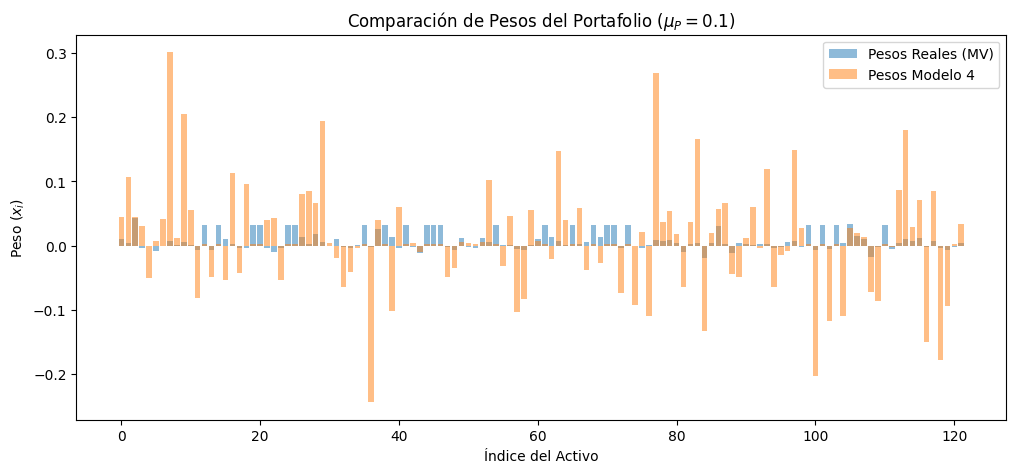

In [38]:
# Comparacion de las ponderaciones obtenidas
pesos_m4, _ = modelo_4(mu=mu_array, mu_P=mu_target,
                       eigenvalores=eigenvalues, eigenvectores=eigenvectors, I=k_90)
plt.figure(figsize=(12, 5))
plt.bar(range(len(pesos_optimos_orig)), pesos_optimos_orig, alpha=0.5, label='Pesos Reales (MV)')
plt.bar(range(len(pesos_m4)), pesos_m4, alpha=0.5, label='Pesos Modelo 4')
plt.title(fr"Comparación de Pesos del Portafolio ($\mu_P = {mu_P}$)")
plt.xlabel("Índice del Activo")
plt.ylabel("Peso ($x_i$)")
plt.legend()
plt.show()

# **Modelo 6**


$$e(x) = \mathbf{x}^{\text{T}}D\mathbf{x}$$



$$M_I^* = \quad \min \quad \sum_{i \in I} \lambda_i z_i^2 + \bar{e}(\mathbf{x}) \nonumber$$
$$\text{s.a.} \quad z_i = P_i^{\text{T}}\mathbf{x}, \quad i \in I \tag{6a}$$
$$\mu^{\text{T}}\mathbf{x} \geq \mu_P \tag{6b}$$
$$\mathbf{x} \in \mathcal{S}. \tag{6c}$$


In [39]:
def modelo_6(mu, mu_P, eigenvalues, eigenvectors, I, Sigma, x_bar):
  """modelo_6
  Funcion que encuentra una aproximacion al portafolio de minima varianza,
  mediante una linealizacion de Taylor para el 'residuo'.
  ---
  params:
    - mu: Array con los rendimientos esperados de los activos.
    - mu_P: Rendimiento mínimo requerido.
    - eigenvalues: Autovalores de la matriz de covarianza.
    - eigenvectors: Matriz de autovectores.
    - I: Cantidad de componentes principales a utilizar.
    - Sigma: Matriz de varianza-covarianza original.
    - x_bar: Punto de expansión (portafolio de referencia) para la serie de Taylor.
  ---
  return:
    - Vector de pesos optimos $x^*$ y el valor de la varianza aproximada
    en el optimo.
  """

  n = len(mu)
  lambda_I_vec = np.zeros(len(eigenvalues))
  lambda_I_vec[:I] = eigenvalues[:I]
  Sigma_I = eigenvectors @ np.diag(lambda_I_vec) @ eigenvectors.T

  D = Sigma - Sigma_I

  const_term = x_bar.T @ D @ x_bar
  grad_term = 2 * (D @ x_bar)

  def objetivo(x):
      var_aprox = 0
      z = eigenvectors.T @ x
      for i in range(I):
          var_aprox += eigenvalues[i] * (z[i] ** 2)
      e_hat = const_term + grad_term.T @ (x - x_bar)
      return var_aprox + max(e_hat, 0)

  restricciones = [{'type': 'ineq', 'fun': lambda x: mu.T @ x - mu_P},
          {'type': 'eq', 'fun': lambda x: np.sum(x) - 1.0}]

  res = minimize(objetivo, x_bar, method='SLSQP', bounds=[(None, None)] * n, constraints=restricciones) # SI VENTAS EN CORTO
  return res.x, res.fun

## Error


In [40]:
## NOTA: esta celda necesita que el modelo 6 permita ventas en CORTO bounds=[(None, None)]*n
# Listas para el Modelo 6
cotas_inferiores_M = []
cotas_superiores_M = []

for i in rango_componentes:
    # 1. Modelo 4
    pesos_aprox, v_i_star = modelo_4(mu=mu_array, mu_P=mu_P,
                                     eigenvalores=eigenvalues,
                                     eigenvectores=eigenvectors, I=i)

    #cotas_inferiores.append(v_i_star)
    #cotas_superiores.append(pesos_aprox.T @ sigma_array @ pesos_aprox)

    # 2. Modelo 6
    # Usamos pesos_aprox (del Modelo 4) como punto de linealizacion x_bar
    pesos_error, m_i_star = modelo_6(mu=mu_array, mu_P=mu_P,
                                     eigenvalues=eigenvalues,
                                     eigenvectors=eigenvectors,
                                     I=i, Sigma=sigma_array,
                                     x_bar=pesos_aprox)

    cotas_inferiores_M.append(m_i_star)
    # Riesgo real evaluado con la matriz completa (M-hat)
    cotas_superiores_M.append(pesos_error.T @ sigma_array @ pesos_error)

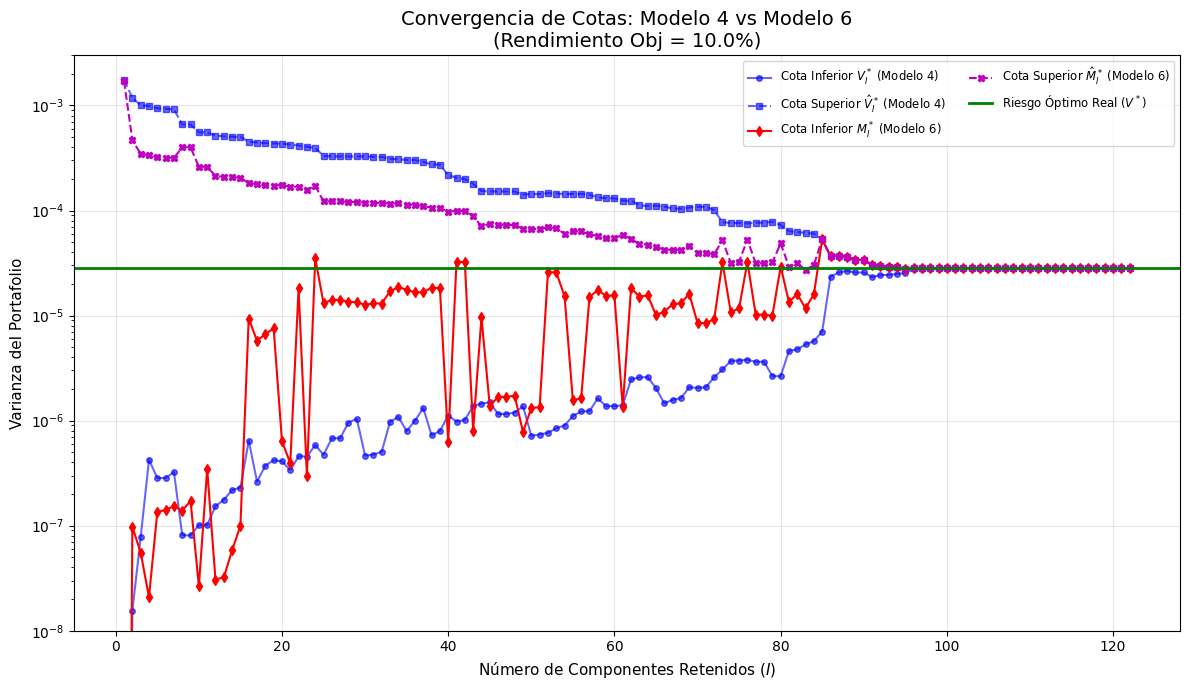

In [41]:
plt.figure(figsize=(12, 7))
plt.plot(rango_componentes, cotas_inferiores, 'b-o', label=r'Cota Inferior $V_I^*$ (Modelo 4)', markersize=4, alpha=0.6)
plt.plot(rango_componentes, cotas_superiores, 'b--s', label=r'Cota Superior $\hat{V}_I^*$ (Modelo 4)', markersize=4, alpha=0.6)
plt.plot(rango_componentes, cotas_inferiores_M, 'r-d', label=r'Cota Inferior $M_I^*$ (Modelo 6)', markersize=5)
plt.plot(rango_componentes, cotas_superiores_M, 'm--X', label=r'Cota Superior $\hat{M}_I^*$ (Modelo 6)', markersize=5)
# Referencia del optimo real
plt.axhline(y=V_optimo, color='g', linestyle='-', linewidth=2, label='Riesgo Óptimo Real ($V^*$)')

plt.title(f'Convergencia de Cotas: Modelo 4 vs Modelo 6\n(Rendimiento Obj = {mu_P*100:.1f}%)', fontsize=14)
plt.xlabel('Número de Componentes Retenidos ($I$)', fontsize=11)
plt.ylabel('Varianza del Portafolio', fontsize=11)
plt.legend(loc='best', fontsize='small', ncol=2)
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.ylim([1e-8, 0.003])
plt.tight_layout()
plt.show()

### *¡El modelo 6 es superior al modelo 4!*

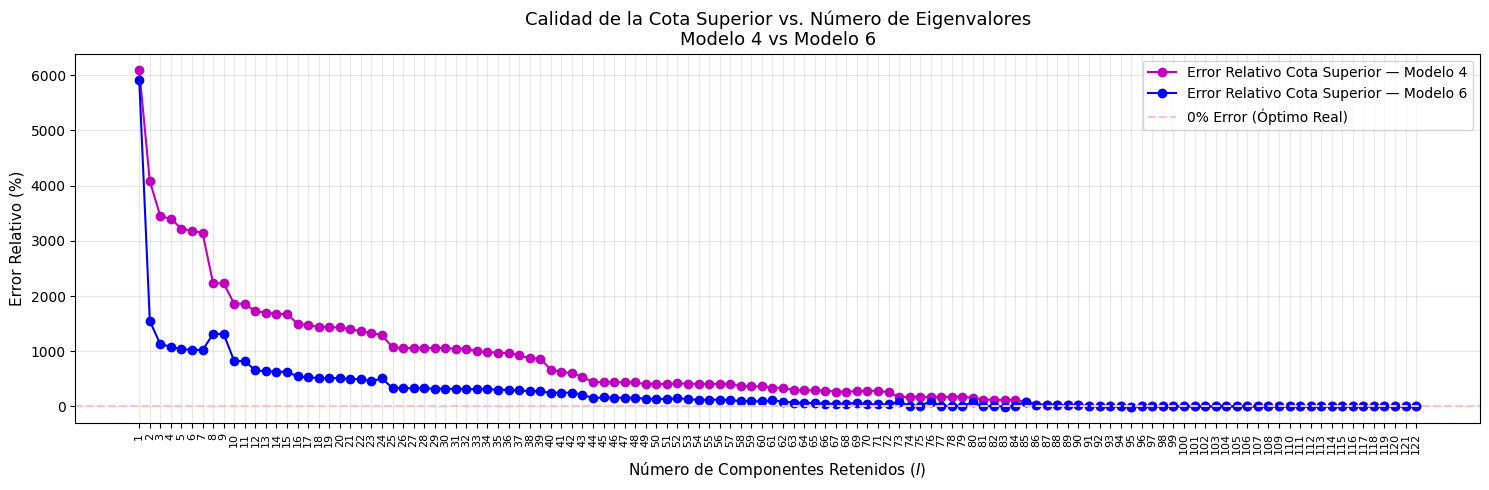

In [42]:
# Calidad de la cota superior — Modelo 6
calidad_cota_superior_M = [((cota_sup - V_optimo) / V_optimo) * 100
                            for cota_sup in cotas_superiores_M]

plt.figure(figsize=(15, 5))

# Modelo 4
plt.plot(rango_componentes, calidad_cota_superior, 'm-o',
         label='Error Relativo Cota Superior — Modelo 4', markersize=6)

# Modelo 6
plt.plot(rango_componentes, calidad_cota_superior_M, 'b-o',
         label='Error Relativo Cota Superior — Modelo 6', markersize=6)

plt.axhline(0, color='pink', linestyle='--', linewidth=1.5, label='0% Error (Óptimo Real)')

plt.title('Calidad de la Cota Superior vs. Número de Eigenvalores\nModelo 4 vs Modelo 6', fontsize=13)
plt.xlabel('Número de Componentes Retenidos ($I$)', fontsize=11)
plt.ylabel('Error Relativo (%)', fontsize=11)
plt.xticks(rango_componentes, rotation=90, fontsize=8)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


**El modelo 6 posee un menor error relativo que el modelo 4.**

In [66]:
print(f"{'':45s} {'Modelo 4':>10} {'Modelo 6':>10}")
print("-" * 70)
print(f"Error máximo usando 1 componente:             "
      f"{calidad_cota_superior[0]:>10.2f}% {calidad_cota_superior_M[0]:>10.2f}%")


# ¡ELIJAN UNA n USTEDES!
n = 56
print(f"Error usando {n} componentes:                 "
      f"{calidad_cota_superior[n-1]:>10.5f}% {calidad_cota_superior_M[n-1]:>10.5f}%")

                                                Modelo 4   Modelo 6
----------------------------------------------------------------------
Error máximo usando 1 componente:                6085.17%    5913.21%
Error usando 56 componentes:                  407.84376%  123.67792%


## **Frontera Eficiente**

In [44]:
rango_mu_P = np.linspace(mu_array.min(), mu_array.max(), 30)
v_star_exacto = []
v_n_inferior = []
v_n_hat_superior = []
m_star_inferior = []
m_hat_superior = []
mu_p_grafica = []

for mu_target in rango_mu_P:
    restricciones_target = [{'type': 'ineq', 'fun': lambda x, r=mu_target: (mu_array.T @ x) - r},
                            {'type': 'eq', 'fun': lambda x: np.sum(x) - 1.0}]
    res_exacto = minimize(
        objetivo_original, x0_orig, method='SLSQP',
        bounds=limites_orig, constraints=restricciones_target)

    if res_exacto.success:
        pesos_v4, v_i_star = modelo_4(mu=mu_array, mu_P=mu_target,
                                                          eigenvalores=eigenvalues,
                                                          eigenvectores=eigenvectors, I=k_90)

        v_n_inferior.append(v_i_star)
        v_n_hat_superior.append(pesos_v4.T @ sigma_array @ pesos_v4)

        pesos_v6, m_i_star = modelo_6(mu=mu_array, mu_P=mu_target, eigenvalues=eigenvalues,
                                      eigenvectors=eigenvectors, I=k_90, Sigma=sigma_array,
                                      x_bar=pesos_v4)

        m_star_inferior.append(m_i_star)
        m_hat_superior.append(pesos_v6.T @ sigma_array @ pesos_v6)

        v_star_exacto.append(res_exacto.fun)
        mu_p_grafica.append(mu_target)

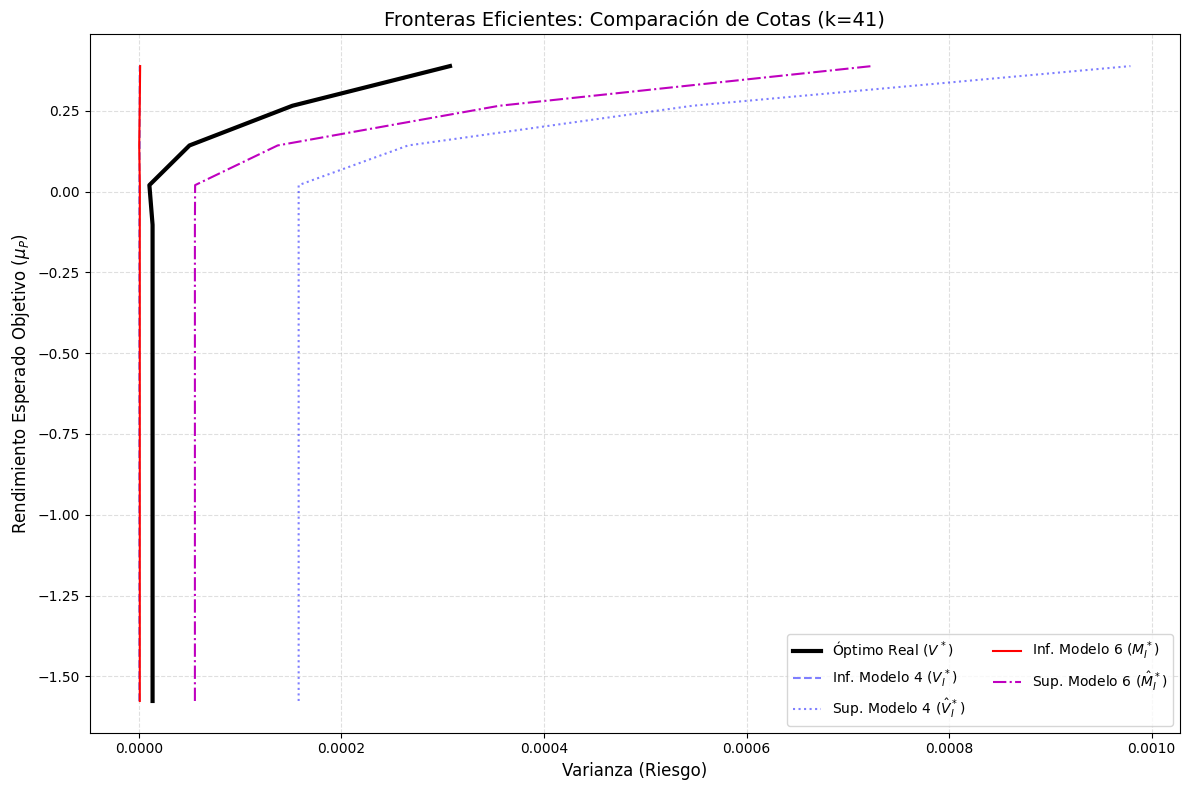

In [45]:
plt.figure(figsize=(12, 8))
plt.plot( v_star_exacto, mu_p_grafica, 'k-', linewidth=3, label=r'Óptimo Real ($V^*$)')
plt.plot( v_n_inferior, mu_p_grafica, 'b--', alpha=0.5, label=r'Inf. Modelo 4 ($V_I^*$)')
plt.plot( v_n_hat_superior, mu_p_grafica, 'b:', alpha=0.5, label=r'Sup. Modelo 4 ($\hat{V}_I^*$)')
plt.plot( m_star_inferior, mu_p_grafica, 'r-', linewidth=1.5, label=r'Inf. Modelo 6 ($M_I^*$)')
plt.plot( m_hat_superior, mu_p_grafica, 'm-.', linewidth=1.5, label=r'Sup. Modelo 6 ($\hat{M}_I^*$)')
plt.title(f'Fronteras Eficientes: Comparación de Cotas (k={k_90})', fontsize=14)
plt.ylabel(r'Rendimiento Esperado Objetivo ($\mu_P$)', fontsize=12)
plt.xlabel('Varianza (Riesgo)', fontsize=12)
#plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x*100:.1f}%'))
plt.legend(loc='best', fontsize=10, ncol=2)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

De igual forma, el modelo 6 se muestra como un mejor método para obtener la frontera eficiente.

In [46]:
print(m_star_inferior)

[np.float64(8.452935087561416e-07), np.float64(8.452935087561416e-07), np.float64(8.452935087561416e-07), np.float64(8.452935087561416e-07), np.float64(8.452935087561416e-07), np.float64(8.452935087561416e-07), np.float64(8.452935087561416e-07), np.float64(8.452935087561416e-07), np.float64(8.452935087561416e-07), np.float64(8.452935087561416e-07), np.float64(8.452935087561416e-07), np.float64(8.452935087561416e-07), np.float64(8.452935087561416e-07), np.float64(9.094976415903279e-07), np.float64(2.792348753835125e-07), np.float64(8.023391978792477e-07), np.float64(1.1918905607919913e-06)]


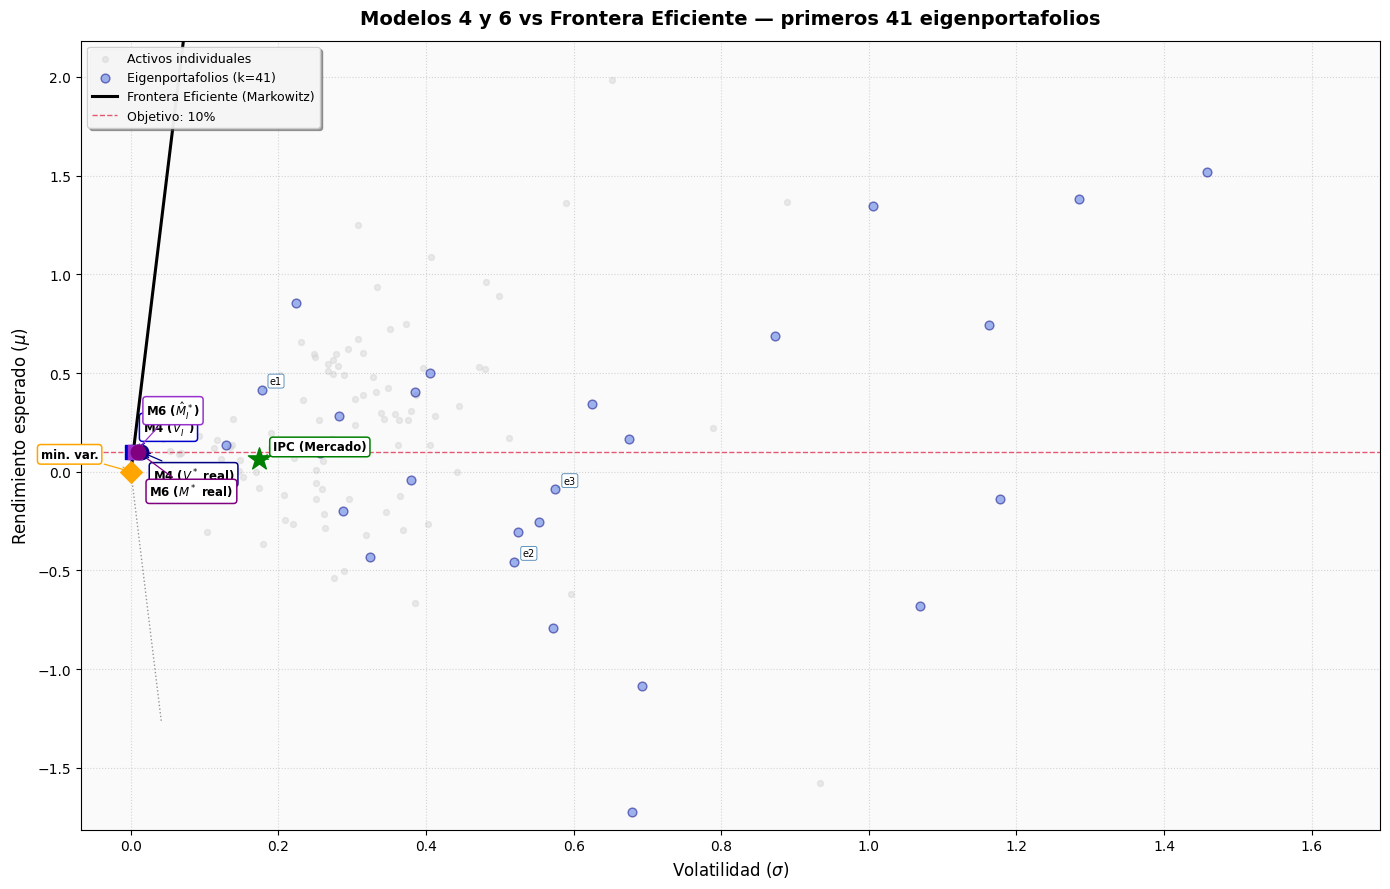

In [47]:
# Modelo 6
x_opt_m6, var_est_m6 = modelo_6(mu=mu_array, mu_P=0.10,
                                  eigenvalues=eigenvalues,
                                  eigenvectors=eigenvectors,
                                  I=k_90,
                                  Sigma=sigma_array,
                                  x_bar=x_opt_m4)
vol_est_m6  = np.sqrt(var_est_m6)
vol_real_m6 = np.sqrt(x_opt_m6.T @ sigma_array @ x_opt_m6)


# Grafica
fig, ax = plt.subplots(figsize=(14, 9))
ax.set_facecolor('#fafafa')
ax.grid(True, linestyle=':', alpha=0.5)

# Activos individuales
ax.scatter(std_activos, mu_array,
           color='lightgray', s=18, alpha=0.45, zorder=1, label='Activos individuales')

# Eigenportafolios
p95_std_eigen = np.nanpercentile(std_eigen, 92)
mask_eigen    = std_eigen <= p95_std_eigen
ax.scatter(std_eigen[mask_eigen], ren_eigen[mask_eigen],
           color='royalblue', s=40, marker='o', edgecolors='navy',
           alpha=0.5, zorder=3, label=f'Eigenportafolios (k={k})')

for i in range(min(5, k)):
    if std_eigen[i] <= p95_std_eigen:
        ax.annotate(f'e{i+1}',
                    xy=(std_eigen[i], ren_eigen[i]),
                    xytext=(6, 4), textcoords='offset points', fontsize=7,
                    bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='steelblue', lw=0.6),
                    arrowprops=dict(arrowstyle='-', color='steelblue', lw=0.6))

# Frontera
ax.plot(sigma_full, r_full,
        color='black', linewidth=1, linestyle=':', alpha=0.4, zorder=4)
ax.plot(sigma_eff, r_eff,
        color='black', linewidth=2.2, label='Frontera Eficiente (Markowitz)', zorder=5)

# Objetivo
ax.axhline(y=0.10, color='crimson', linestyle='--', linewidth=1, alpha=0.7, label='Objetivo: 10%')

# Puntos especiales
puntos = {
    'IPC (Mercado)':       (std_index,   mu_index, 'green',      '*',  280, ( 10,  6)),
    'min. var.':           (std_gmvp,    ren_gmvp, 'orange',     'D',  120, (-65, 10)),
    r'M4 ($\hat{V}_I^*$)': (std_est_m4,  0.10,     'mediumblue', 's',  110, (  8, 14)),
    r'M4 ($V^*$ real)':    (std_real_m4, 0.10,     'navy',       'o',  110, (  8,-20)),
    r'M6 ($\hat{M}_I^*$)': (vol_est_m6,  0.10,     'darkorchid', 's',  110, (  8, 26)),
    r'M6 ($M^*$ real)':    (vol_real_m6, 0.10,     'purple',     'o',  110, (  8,-32)),
}
for label, (vx, ry, col, mk, sz, (ox, oy)) in puntos.items():
    ax.scatter(vx, ry, color=col, marker=mk, s=sz, zorder=6)
    ax.annotate(label, xy=(vx, ry),
                xytext=(ox, oy), textcoords='offset points',
                fontsize=8.5, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.28', fc='white', ec=col, lw=1.1),
                arrowprops=dict(arrowstyle='->', color=col, lw=0.9))

p95_v = np.nanpercentile(np.concatenate([std_eigen[mask_eigen], std_activos]), 95)
x_max = max(p95_v, std_real_m4, vol_real_m6) * 1.3
ax.set_xlim(-x_max * 0.04, x_max)
ax.set_ylim(mu_array.min() * 1.15, mu_array.max() * 1.1)
ax.set_xlabel(r'Volatilidad ($\sigma$)', fontsize=12)
ax.set_ylabel(r'Rendimiento esperado ($\mu$)', fontsize=12)
ax.set_title(f'Modelos 4 y 6 vs Frontera Eficiente — primeros {k} eigenportafolios',
             fontsize=14, fontweight='bold', pad=12)
ax.legend(loc='upper left', fontsize=9, frameon=True, framealpha=0.9, shadow=True)
plt.tight_layout()
#plt.savefig('frontera_modelos.png', dpi=150, bbox_inches='tight')
plt.show()

### **¡Lo hemos vuelto a lograr!**
Y de una manera aún más óptima, eficiente y con un menor error relativo.

In [48]:
import plotly.graph_objects as go

vol_activos = np.sqrt(np.diag(sigma_array))

fig = go.Figure()

# Acciones
fig.add_trace(go.Scatter(
    x=vol_activos, y=mu_array,
    mode='markers',
    marker=dict(color='lightgray', size=5, opacity=0.5,
                line=dict(color='gray', width=0.3)),
    name='Activos individuales',
    hovertemplate='σ=%{x:.4f}<br>μ=%{y:.4f}<extra></extra>'))

# Eigenportafolios
p95 = np.nanpercentile(std_eigen, 92)
mask_e = std_eigen <= p95
hover_eigen = [f'e{i+1}<br>σ={std_eigen[i]:.4f}<br>μ={ren_eigen[i]:.4f}'
               for i in range(k)]

fig.add_trace(go.Scatter(
    x=std_eigen[mask_e], y=ren_eigen[mask_e],
    mode='markers+text',
    marker=dict(color='royalblue', size=8, opacity=0.7,
                line=dict(color='navy', width=1)),
    text=[f'e{i+1}' if i < 5 else '' for i in np.where(mask_e)[0]],
    textposition='top right',
    textfont=dict(size=9, color='steelblue'),
    name=f'Eigenportafolios (k={k})',
    hovertext=[hover_eigen[i] for i in np.where(mask_e)[0]],
    hoverinfo='text'))

# Frontera completa
fig.add_trace(go.Scatter(
    x=sigma_full, y=r_full,
    mode='lines',
    line=dict(color='black', width=1, dash='dot'),
    opacity=0.35,
    name='Frontera completa',
    hoverinfo='skip'))

# Frontera eficiente
fig.add_trace(go.Scatter(
    x=sigma_eff, y=r_eff,
    mode='lines',
    line=dict(color='black', width=2.5),
    name='Frontera Eficiente (Markowitz)',
    hovertemplate='σ=%{x:.4f}<br>μ=%{y:.4f}<extra>Frontera</extra>'
))

# Rendimiento Objetivo
fig.add_hline(y=0.10, line=dict(color='crimson', dash='dash', width=1.5),
              opacity=0.7, annotation_text='Objetivo 10%',
              annotation_position='right')

# Puntos especiales
puntos = {'IPC (Mercado)':       (std_index,   mu_index, 'green',      'star',           16),
        'min. var.':           (std_gmvp,    ren_gmvp, 'orange',     'diamond',        12),
        r'M4 V̂_I*':           (std_est_m4,  0.10,     'mediumblue', 'square',         12),
        r'M4 V* real':         (std_real_m4, 0.10,     'navy',       'circle',         12),
        r'M6 M̂_I*':           (vol_est_m6,  0.10,     'darkorchid', 'square',         12),
        r'M6 M* real':         (vol_real_m6, 0.10,     'purple',     'circle',         12)}

for label, (vx, ry, col, sym, sz) in puntos.items():
    fig.add_trace(go.Scatter(
        x=[vx], y=[ry],
        mode='markers+text',
        marker=dict(color=col, symbol=sym, size=sz,
                    line=dict(color='white', width=1)),
        text=[label],
        textposition='top right',
        textfont=dict(size=10, color=col),
        name=label,
        hovertemplate=f'<b>{label}</b><br>σ=%{{x:.5f}}<br>μ=%{{y:.4f}}<extra></extra>'))

# solo nos quedamos con el percentil 95 de los activos
p95_v = np.nanpercentile(np.concatenate([std_eigen[mask_e], std_activos]), 95)
x_max = max(p95_v, std_real_m4, vol_real_m6) * 1.3
fig.update_layout(
    title=dict(
        text=f'Modelos 4 y 6 vs Frontera Eficiente — primeros {k} eigenportafolios',
        font=dict(size=16, color='#222'),
        x=0.5
    ),
    xaxis=dict(
        title='Volatilidad (σ)',
        range=[-x_max * 0.04, x_max],
        gridcolor='#ebebeb', gridwidth=1,
        zeroline=True, zerolinecolor='#aaa', zerolinewidth=1
    ),
    yaxis=dict(
        title='Rendimiento esperado (μ)',
        range=[mu_array.min() * 1.15, mu_array.max() * 1.1],
        gridcolor='#ebebeb', gridwidth=1
    ),
    legend=dict(
        x=0.01, y=0.99,
        bgcolor='rgba(255,255,255,0.85)',
        bordercolor='#ccc', borderwidth=1,
        font=dict(size=10),orientation='h'
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    width=1100, height=700,
    hovermode='closest')

fig.show()

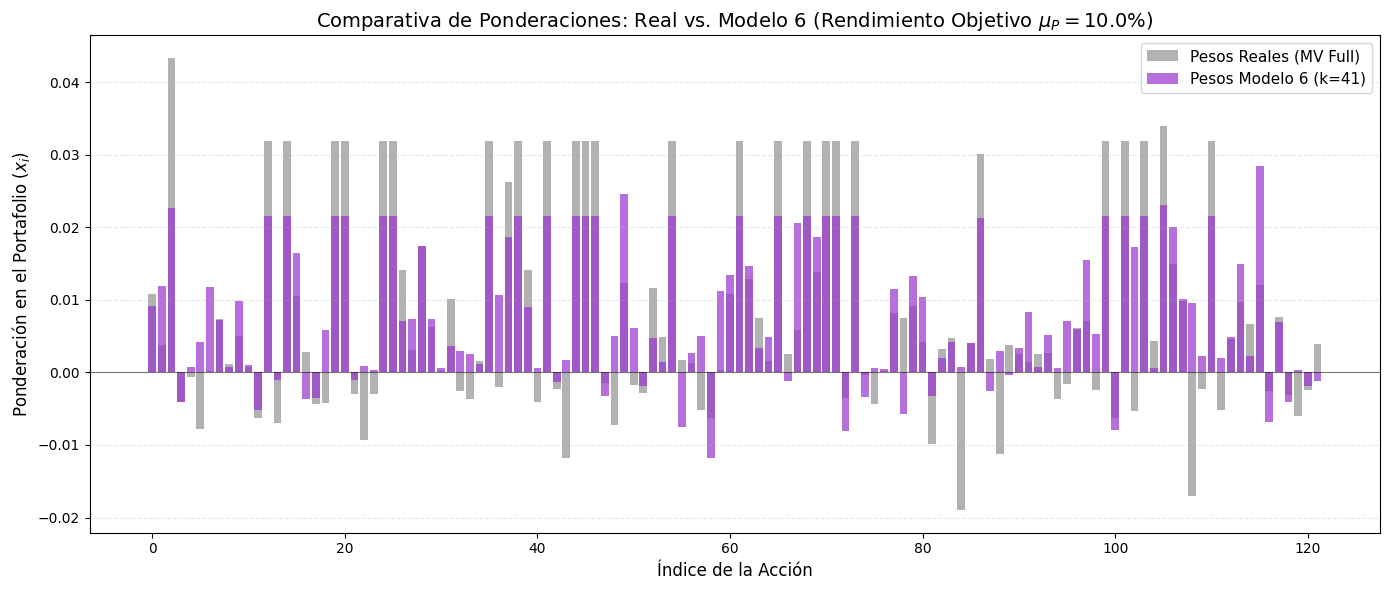

In [49]:
plt.figure(figsize=(14, 6))
plt.bar(range(len(pesos_optimos_orig)), pesos_optimos_orig,
        alpha=0.6, color='gray', label='Pesos Reales (MV Full)')
plt.bar(range(len(x_opt_m6)), x_opt_m6,
        alpha=0.7, color='darkorchid', label=f'Pesos Modelo 6 (k={k_90})')
plt.title(
    fr"Comparativa de Ponderaciones: Real vs. Modelo 6 (Rendimiento Objetivo $\mu_P = {mu_P*100:.1f}$%)",
    fontsize=14)
plt.xlabel("Índice de la Acción", fontsize=12)
plt.ylabel("Ponderación en el Portafolio ($x_i$)", fontsize=12)
plt.axhline(0, color='black', linewidth=0.8, alpha=0.5)
plt.legend(loc='upper right', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

Existe consenso con acciones con ponderaciones mayores.


# ¿Y si mis 2GB de RAM no dan y quiero reducir aún más información?

En vez de trabajar directamente con las variables originales, podemos trabajar con una simple relación lineal:

$$y_i = (\mu_i -r_b)\cdot x_i$$

Lo que buscamos es *escalar*: Quitamos el exceso de rendimiento, calculando el peso *real* de cada eigenportfolio. Así, ¡puedes reducir aún más la información!

Esto convierte el problema de minimzación original al siguiente:

$$x^T\Sigma x = y^TD\Sigma D y = y^T Q y$$

## ¿Y eso con qué se come o cómo funciona?

Por construcción, la nueva matriz **Q** sigue siendo una matriz de covarianzas simétrica y definida positiva *(teóricamente)*. Calcular sus eigenvalores es igual de complejo, pero al estar bien diferenciados, llega a ser ligeramente mas rápido.

Eso sí, no sabemos a ciencia exacta cómo calcular el exceso de rendimiento a aplicar. Empíricamente, sabemos que debe estar entre el máximo y mínimo rendimiento esperado sin ser exactamente igual a alguno, para evitar indeterminaciones.

In [50]:
def transformar_modelo_Q(mu, Sigma, r_b):
    """transformar_modelo_Q
    Funcion que factoriza la matriz de covarianzas Sigma a Q
    ---
    params:
    - mu: Array con los rendimientos esperados de los activos.
    - Sigma: Matriz de varianza-covarianza original.
    - r_b: Exceso de rendimiento
    ---
    return:
    - Q: Matriz transformada Q
    - D_mat: Matriz de diagonal con los inversos de los rendimientos esperados.
    """
    D_diag = 1.0 / (mu - r_b)
    D_mat = np.diag(D_diag)
    Q = D_mat @ Sigma @ D_mat
    return Q, D_mat

Aviso: Saltando r_b = 0.0 porque choca con el rendimiento de un activo y causa división por 0.


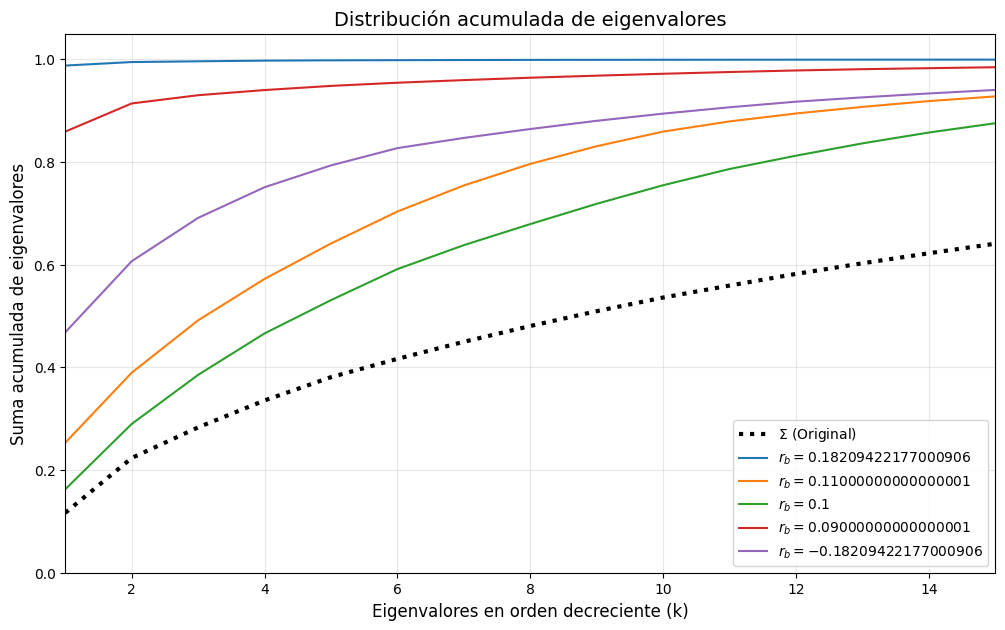

In [51]:
mu_min = mu_array.min()
mu_max = mu_array.max()
mu_promedio = mu_array.mean()

# Generamos r_bs basados en mu_P y el promedio de loss activos
# Lista con valores un poco por encima y por debajo de mu_P
valores_rb = [
    mu_P * 1.1, # 10% arriba
    mu_P, # exacto
    mu_P * 0.9, # 10% abajo
    mu_promedio, # promedio de tus activos
    0.0, # Caso base
    -mu_promedio # Simetria
]

# Ordenamos para la gráfica
valores_rb = sorted(list(set(valores_rb)), reverse=True)

plt.figure(figsize=(12, 7))
evs_original = np.sort(eigenvalues)[::-1]
suma_acum_sigma = np.cumsum(evs_original) / np.sum(evs_original)
plt.plot(range(1, len(suma_acum_sigma) + 1), suma_acum_sigma,
         label=r'$\Sigma$ (Original)', linestyle=':', color='black', linewidth=3)

# Graficamos la matriz transformada Q para cada r_b
for rb in valores_rb:

  if np.any(np.isclose(mu_array, rb, atol=1e-7)):
      print(f"Aviso: Saltando r_b = {rb} porque choca con el rendimiento de un activo y causa división por 0.")
      continue

  D_diag = 1.0 / (mu_array - rb)
  D = np.diag(D_diag)

  Q = D @ sigma_array @ D

  evs_Q = np.linalg.eigvals(Q)
  evs_Q = np.sort(evs_Q)[::-1]

  suma_acum_Q = np.cumsum(evs_Q) / np.sum(evs_Q)

  plt.plot(range(1, len(suma_acum_Q) + 1), suma_acum_Q, label=f'$r_b = {rb}$')

plt.title("Distribución acumulada de eigenvalores", fontsize=14)
plt.xlabel("Eigenvalores en orden decreciente (k)", fontsize=12)
plt.ylabel("Suma acumulada de eigenvalores", fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.xlim(1, 15)
plt.ylim(0, 1.05)

plt.show()

#### Claramente podemos reducir la información que necesitamos emplear.

In [52]:
r_b    = mu_P * 0.80
denom  = mu_array - r_b
pos    = denom > 0
n_act  = len(mu_array)

# ── Aseguramos que Q y sus eigenvectores están calculados (cell 78) ──────────
Q_mat, D_mat_q = transformar_modelo_Q(mu_array, sigma_array, r_b)
Q_mat = (Q_mat + Q_mat.T) / 2
eigs_Q_loc, evecs_Q_loc = np.linalg.eigh(Q_mat)
idx_Q_loc   = np.argsort(eigs_Q_loc)[::-1]
eigs_Q_loc  = eigs_Q_loc[idx_Q_loc]
evecs_Q_loc = evecs_Q_loc[:, idx_Q_loc]

def _resolver_Q_mod4(k, eigs_q, evecs_q):
    """Resuelve Modelo 4 en espacio Q y devuelve x en espacio original."""
    lam_k = eigs_q[:k]
    P_k   = evecs_q[:, :k]
    Q_k   = (P_k * lam_k) @ P_k.T

    bounds_y = [(0, None) if p else (None, 0) for p in pos]
    y0 = np.where(pos, 1.0 / (denom * n_act), 0.0)

    res = minimize(
        lambda y: float(lam_k @ (P_k.T @ y) ** 2),
        y0, jac=lambda y: 2.0 * Q_k @ y,
        method='SLSQP', bounds=bounds_y,
        constraints=[
            {'type': 'eq',   'fun': lambda y: denom @ y - 1.0},
            {'type': 'ineq', 'fun': lambda y: (mu_array * denom) @ y - mu_P},
        ],
        options={'ftol': 1e-10, 'maxiter': 1000}
    )
    x_opt = denom * res.x          # volver al espacio original
    return x_opt

def _resolver_Q_mod6(k, eigs_q, evecs_q, x_bar_orig):
    """Resuelve Modelo 6 en espacio Q y devuelve x en espacio original."""
    lam_k  = eigs_q[:k]
    P_k    = evecs_q[:, :k]
    Q_k    = (P_k * lam_k) @ P_k.T
    Q_err  = Q_mat - Q_k
    y_bar  = x_bar_orig / denom           # punto de linealización en espacio y
    c_bar  = float(y_bar @ Q_err @ y_bar)
    g_bar  = 2.0 * (Q_err @ y_bar)

    bounds_yw = [(0, None) if p else (None, 0) for p in pos] + [(0, None)]
    yw0 = np.append(np.where(pos, 1.0 / (denom * n_act), 0.0), 0.0)

    def obj(yw):
        y, w = yw[:n_act], yw[n_act]
        return float(lam_k @ (P_k.T @ y) ** 2) + w

    def jac(yw):
        return np.append(2.0 * Q_k @ yw[:n_act], 1.0)

    e_const = c_bar - float(g_bar @ y_bar)
    res = minimize(
        obj, yw0, jac=jac, method='SLSQP', bounds=bounds_yw,
        constraints=[
            {'type': 'eq',   'fun': lambda yw: denom @ yw[:n_act] - 1.0},
            {'type': 'ineq', 'fun': lambda yw: (mu_array * denom) @ yw[:n_act] - mu_P},
            {'type': 'ineq', 'fun': lambda yw: yw[n_act] - (e_const + g_bar @ yw[:n_act])},
        ],
        options={'ftol': 1e-10, 'maxiter': 1000}
    )
    x_opt = denom * res.x[:n_act]
    return x_opt

# ── Pesos de cada portafolio ─────────────────────────────────────────────────

# PCA (top k_90 eigenvectores de Σ)
x_pca_m4 = pesos_optimos_aprox
x_pca_m6, _ = modelo_6(mu_array, mu_P, eigenvalues, eigenvectors,
                                 k_90, sigma_array, x_pca_m4)

# Transformación Q – Modelo 4 y 6 (PCA sobre Q con k_90 componentes)
x_Q_m4 = _resolver_Q_mod4(k_90, eigs_Q_loc, evecs_Q_loc)
x_Q_m6 = _resolver_Q_mod6(k_90, eigs_Q_loc, evecs_Q_loc, x_Q_m4)

# Calcular μ y σ reales de cada portafolio
def _stats(x):
    mu_p = float(mu_array @ x)
    std_p = float(np.sqrt(x @ sigma_array @ x))
    return std_p, mu_p

std_real,     mu_real     = _stats(pesos_optimos_orig)
std_pca_m4,   mu_pca_m4   = _stats(x_pca_m4)
std_pca_m6,   mu_pca_m6   = _stats(x_pca_m6)
std_Q_m4,     mu_Q_m4     = _stats(x_Q_m4)
std_Q_m6,     mu_Q_m6     = _stats(x_Q_m6)

# Recalculamos v_star_exacto:
if 'v_star_exacto' not in dir() or len(v_star_exacto) == 0:
    rango_fe = np.linspace(mu_array.min(), mu_array.max(), 30)
    v_star_exacto, mu_p_grafica = [], []
    for mu_t in rango_fe:
        res_fe = minimize(objetivo_original, x0_orig, method='SLSQP',
                          bounds=limites_orig,
                          constraints=[{'type':'ineq','fun':lambda x,r=mu_t: mu_array@x-r},
                                       {'type':'eq',  'fun':lambda x: np.sum(x)-1}])
        if res_fe.success:
            v_star_exacto.append(res_fe.fun)
            mu_p_grafica.append(mu_t)

std_frontera = np.sqrt(v_star_exacto)

## **Comparación de la calidad de la cota superior entre el modelo transformado y el no transformado.**

In [53]:
# Parámetro de transformación
r_b = mu_P * 0.80

# Rango de k a evaluar
n_activos = len(mu_array)
rango_k   = range(1, n_activos + 1)

# Contenedores para las 4 curvas de desviación
dev_Vhat = []   # modelo 4 sin transformar
dev_Mhat = []   # modelo 6 con error sin transformar
dev_That = []   # modelo 4 CON transformar  (Q)
dev_Ehat = []   # modelo 6 con error CON transformar (Q)

# Pre-calcular la matriz Q y su eigendescomposición
Q, D_mat = transformar_modelo_Q(mu_array, sigma_array, r_b)
Q = (Q + Q.T) / 2  # garantizar simetría numérica
eigs_Q, evecs_Q = np.linalg.eigh(Q)
idx_Q = np.argsort(eigs_Q)[::-1]
eigs_Q  = eigs_Q[idx_Q]
evecs_Q = evecs_Q[:, idx_Q]

# cota superior del modelo transformado
def resolver_transformado_k(k):
    """
    Resuelve el problema aproximado (4) en el espacio transformado y
    regresa la cota superior evaluada en el espacio original
    """
    denom = mu_array - r_b
    pos = denom > 0

    lam_k = eigs_Q[:k]
    P_k = evecs_Q[:, :k]
    Q_k = (P_k * lam_k) @ P_k.T

    def objetivo(y):
        z = P_k.T @ y
        return float(lam_k @ (z ** 2))

    def grad_obj(y):
        return 2.0 * Q_k @ y

    bounds = [(0, None) if p else (None, 0) for p in pos]
    y0 = np.where(pos, 1.0 / (denom * n_activos), 0.0)

    res = minimize(
        objetivo, y0, jac=grad_obj, method='SLSQP',
        bounds=bounds,
        constraints=[
            {'type': 'eq',  'fun': lambda y: denom @ y - 1.0},
            {'type': 'ineq','fun': lambda y: (mu_array * denom) @ y - mu_P},
        ],
        options={'ftol': 1e-10, 'maxiter': 1000}
    )

    y_opt = res.x
    x_opt = denom * y_opt # volver al espacio original
    T_hat = float(x_opt @ sigma_array @ x_opt) # cota superior en Σ original
    return T_hat


# cota superior del modelo 6 transformado
def resolver_transformado_linealizado_k(k, x_bar_trans):
    """
    Problema (6) en el espacio transformado: añade el término de error
    linealizado ê(y) = ȳᵀ(Q-Q_k)ȳ + 2[(Q-Q_k)ȳ]ᵀ(y-ȳ)
    y regresa la cota superior en el espacio original.
    """
    denom = mu_array - r_b
    pos   = denom > 0

    lam_k = eigs_Q[:k]
    P_k   = evecs_Q[:, :k]
    Q_k   = (P_k * lam_k) @ P_k.T
    Q_err = Q - Q_k # error matrix en espacio Q

    # Punto de linealización en espacio y
    y_bar = x_bar_trans / denom

    c_bar = float(y_bar @ Q_err @ y_bar)
    g_bar = 2.0 * (Q_err @ y_bar)
    e_const = c_bar - float(g_bar @ y_bar)

    def objetivo(yw):
        y, w = yw[:n_activos], yw[n_activos]
        z = P_k.T @ y
        return float(lam_k @ (z ** 2)) + w

    def grad_obj(yw):
        y = yw[:n_activos]
        return np.append(2.0 * Q_k @ y, 1.0)

    bounds_y = [(0, None) if p else (None, 0) for p in pos]
    bounds   = bounds_y + [(0, None)]
    yw0      = np.append(np.where(pos, 1.0/(denom*n_activos), 0.0), 0.0)

    res = minimize(
        objetivo, yw0, jac=grad_obj, method='SLSQP',
        bounds=bounds,
        constraints=[
            {'type': 'ineq', 'fun': lambda yw: yw[n_activos]},
            {'type': 'ineq', 'fun': lambda yw: yw[n_activos] - e_const - g_bar @ yw[:n_activos]},
            {'type': 'eq',   'fun': lambda yw: denom @ yw[:n_activos] - 1.0},
            {'type': 'ineq', 'fun': lambda yw: (mu_array * denom) @ yw[:n_activos] - mu_P},
        ],
        options={'ftol': 1e-10, 'maxiter': 1000}
    )

    y_opt = res.x[:n_activos]
    x_opt = denom * y_opt
    E_hat = float(x_opt @ sigma_array @ x_opt)
    return E_hat


# Bucle principal sobre k
print("Calculando desviaciones para cada k...")

for k in rango_k:

    # 1. Modelo 4 sin transformar (V̂_I*)
    pesos_aprox, _ = modelo_4(
        mu_array, mu_P, eigenvalues, eigenvectors, k)
    Vhat = float(pesos_aprox @ sigma_array @ pesos_aprox)
    dev_Vhat.append(abs(Vhat - V_optimo))

    # 2. Modelo 6 con error sin transformar  (M̂_I*)
    x_E, _ = modelo_6(
        mu_array, mu_P, eigenvalues, eigenvectors, k, sigma_array, pesos_aprox)
    Mhat = float(x_E @ sigma_array @ x_E)
    dev_Mhat.append(abs(Mhat - V_optimo))

    # 3. Modelo 4 CON transformación Q  (T̂_I*)
    try:
        That = resolver_transformado_k(k)
        dev_That.append(abs(That - V_optimo))
    except Exception:
        dev_That.append(np.nan)

    # 4. Modelo 6 CON transformación Q  (Ê_I*)
    try:
        Ehat = resolver_transformado_linealizado_k(k, pesos_aprox)
        dev_Ehat.append(abs(Ehat - V_optimo))
    except Exception:
        dev_Ehat.append(np.nan)

    if k % 10 == 0:
        print(f"  k={k}/{n_activos}  |  V̂-V*={dev_Vhat[-1]:.2e}  "
              f"M̂-V*={dev_Mhat[-1]:.2e}  T̂-V*={dev_That[-1]:.2e}  "
              f"Ê-V*={dev_Ehat[-1]:.2e}")

# Cota teórica: λ_max del residuo
# Para cada k el mayor eigenvalor no utilizado
lambda_max_lista = [eigenvalues[k] if k < n_activos else 0 for k in rango_k]

ks = list(rango_k)
lambda_max_lista = [eigenvalues[k] if k < n_activos else 0 for k in rango_k]

Calculando desviaciones para cada k...
  k=10/122  |  V̂-V*=5.26e-04  M̂-V*=2.32e-04  T̂-V*=6.30e-03  Ê-V*=5.50e-03
  k=20/122  |  V̂-V*=4.05e-04  M̂-V*=1.47e-04  T̂-V*=1.97e-02  Ê-V*=1.54e-02
  k=30/122  |  V̂-V*=3.00e-04  M̂-V*=9.06e-05  T̂-V*=5.50e-04  Ê-V*=5.50e-04
  k=40/122  |  V̂-V*=1.89e-04  M̂-V*=6.90e-05  T̂-V*=4.15e-04  Ê-V*=4.15e-04
  k=50/122  |  V̂-V*=1.15e-04  M̂-V*=3.83e-05  T̂-V*=4.28e-04  Ê-V*=4.28e-04
  k=60/122  |  V̂-V*=1.02e-04  M̂-V*=2.63e-05  T̂-V*=4.32e-04  Ê-V*=4.31e-04
  k=70/122  |  V̂-V*=8.03e-05  M̂-V*=1.10e-05  T̂-V*=4.39e-04  Ê-V*=4.39e-04
  k=80/122  |  V̂-V*=4.44e-05  M̂-V*=2.04e-05  T̂-V*=4.32e-04  Ê-V*=4.32e-04
  k=90/122  |  V̂-V*=5.55e-06  M̂-V*=5.55e-06  T̂-V*=4.32e-04  Ê-V*=4.32e-04
  k=100/122  |  V̂-V*=6.15e-15  M̂-V*=6.15e-15  T̂-V*=4.78e-04  Ê-V*=4.78e-04
  k=110/122  |  V̂-V*=2.85e-14  M̂-V*=2.85e-14  T̂-V*=4.78e-04  Ê-V*=4.78e-04
  k=120/122  |  V̂-V*=4.20e-14  M̂-V*=4.20e-14  T̂-V*=4.78e-04  Ê-V*=4.78e-04


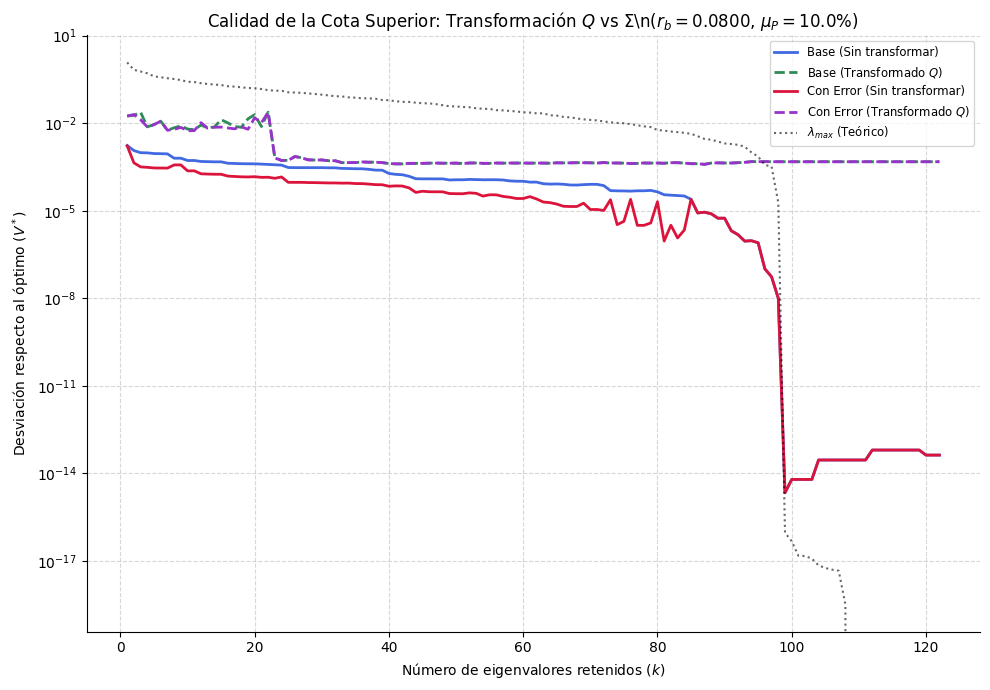

In [54]:
plt.figure(figsize=(10, 7))

plt.title(rf"Calidad de la Cota Superior: Transformación $Q$ vs $\Sigma$\n"
          rf"($r_b = {r_b:.4f}$, $\mu_P = {mu_P*100:.1f}\%$)")

# Usamos escalas de colores coherentes: Azules/Verdes para base, Rojos/Magentas para error
plt.semilogy(ks, dev_Vhat, color='royalblue', ls='-',  lw=2, label='Base (Sin transformar)')
plt.semilogy(ks, dev_That, color='seagreen',  ls='--', lw=2, label='Base (Transformado $Q$)')
plt.semilogy(ks, dev_Mhat, color='crimson',   ls='-',  lw=2, label='Con Error (Sin transformar)')
plt.semilogy(ks, dev_Ehat, color='darkorchid',ls='--', lw=2, label='Con Error (Transformado $Q$)')

# La cota teórica como referencia visual
plt.semilogy(ks, lambda_max_lista, color='black', ls=':', alpha=0.6, label=r'$\lambda_{max}$ (Teórico)')

plt.xlabel(r"Número de eigenvalores retenidos ($k$)")
plt.ylabel(r"Desviación respecto al óptimo ($V^*$)")
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend(frameon=True, loc='best', fontsize='small')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

#### Perdemos información pero mantenemos un error un poco mayor.

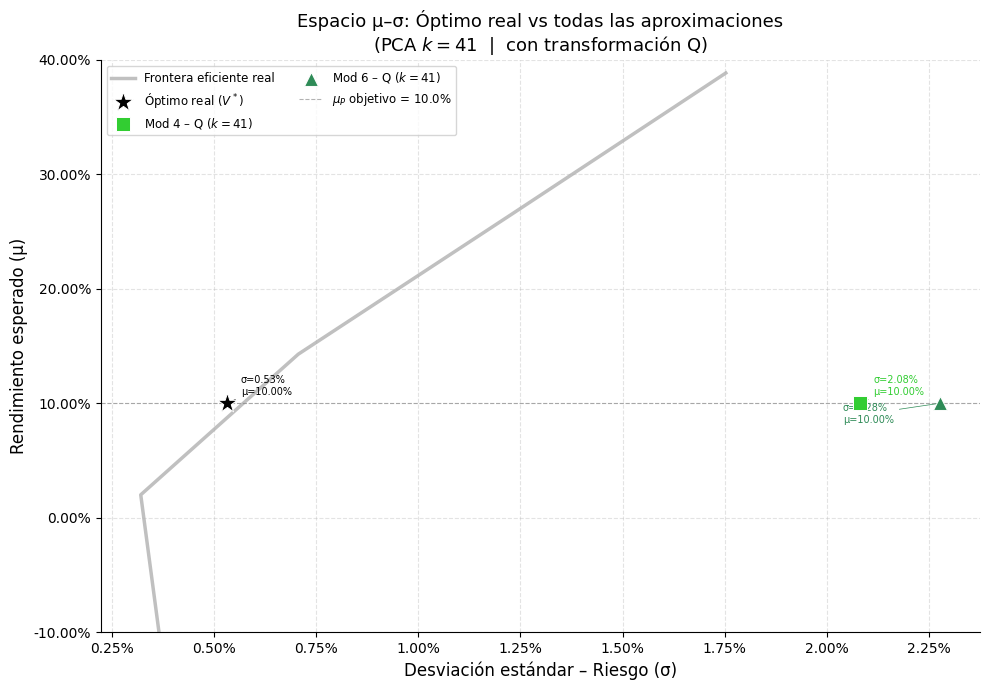

In [55]:
fig, ax = plt.subplots(figsize=(10, 7))

# ── Frontera eficiente real (fondo) ─────────────────────────────────────────
ax.plot(std_frontera, mu_p_grafica,
        color='silver', lw=2.5, zorder=1, label='Frontera eficiente real')

# ── Puntos de cada portafolio ────────────────────────────────────────────────
#   (std, mu, label, color, marker, size)
portafolios = [
    (std_real,    mu_real,    "Óptimo real $(V^*)$",                  "black",      "★",  220),
    (std_Q_m4,    mu_Q_m4,    f"Mod 4 – Q ($k={k_90}$)",             "limegreen",  "s",  100),
    (std_Q_m6,    mu_Q_m6,    f"Mod 6 – Q ($k={k_90}$)",             "seagreen",   "^",  100)
]

# Agrupamos las etiquetas de anotación a la derecha / arriba para evitar solapamiento
offsets = [(10, 6), (10, 6), (-70, -14)]
for (std, mu, label, color, marker, size), (dx, dy) in zip(portafolios, offsets):
    ax.scatter(std, mu, label=label, color=color,
               marker=marker if marker != "★" else "*",
               s=size, zorder=5, edgecolors="white", linewidths=0.7)
    ax.annotate(
        f"σ={std*100:.2f}%\nμ={mu*100:.2f}%",
        xy=(std, mu), xytext=(dx, dy), textcoords="offset points",
        fontsize=7, color=color,
        arrowprops=dict(arrowstyle="-", color=color, lw=0.5) if abs(dx) > 9 else None,
    )

# ── Línea de μ_P objetivo ────────────────────────────────────────────────────
ax.axhline(mu_P, color="gray", lw=0.8, ls="--", alpha=0.6,
           label=f"$\\mu_P$ objetivo = {mu_P*100:.1f}%")

# ── Formato ──────────────────────────────────────────────────────────────────
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v*100:.2f}%"))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v*100:.2f}%"))
ax.set_xlabel("Desviación estándar – Riesgo (σ)", fontsize=12)
ax.set_ylabel("Rendimiento esperado (μ)", fontsize=12)
ax.set_title(
    f"Espacio μ–σ: Óptimo real vs todas las aproximaciones\n"
    f"(PCA $k={k_90}$  |  con transformación Q)",
    fontsize=13
)
ax.legend(frameon=True, fontsize=8.5, ncol=2, loc="best")
ax.grid(True, linestyle="--", alpha=0.35)
ax.spines[["top", "right"]].set_visible(False)
plt.ylim([-0.1, 0.4])
plt.tight_layout()
plt.show()

#### Al emplear la transformación Q empeora un poco el desempeño de los modelos.

# **Enfoque 2:** Selección usando Lasso

$$\min_{w} \left( \frac{1}{2 \cdot n_{\text{samples}}} \||y - Xw\||_2^2 + \alpha \|w\|_1 \right)$$

donde:

$$n_{\text{samples}} \text{: Representa el número de muestras en datos de entrenamiento.}$$
$$y \text{: etiquetas = valores reales de los rendimientos}$$
$$Xw \text{: Representa los valores predichos por el modelo. X es la matriz de características (eigenvectores) y w es el vector de coeficientes.}$$
 $$ \text{Factor de penalización} ⇒ \alpha \text{: parámetro de regularización.}$$

In [56]:
from sklearn.linear_model import LassoCV, Lasso
from sklearn.model_selection import TimeSeriesSplit

y_hist ≈ Z_hist @ w  +  intercepto

In [57]:
rendimientos_log_matriz = rendimientos_log.values

print(f"Shape: {rendimientos_log_matriz.shape}")
print(f"{rendimientos_log_matriz.shape[1] == len(mu_array)}") # Coincide con tamanio de los rendimientos que teniamos

# Proyectamos al espacio PCA
Z_hist = rendimientos_log_matriz @ eigenvectors # rendimientos historicos
y_hist = rendimientos_log_matriz.mean(axis=1) # rendimiento promedio diarios del mercado
print(len(y_hist))

Shape: (132, 122)
True
132


In [58]:
# TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5,
                       gap=5) # para evitar que la correlacion entre ultimos días de entrenamiento y los primeros de test

lasso_cv = LassoCV(cv=tscv,
                   fit_intercept=True,
                   max_iter=10_000,
                   n_alphas=200, # sklearn elige alfas
                   n_jobs=-1,
                   random_state=42)

lasso_cv.fit(Z_hist, y_hist)

alpha_optimo = lasso_cv.alpha_
coefs_lasso  = lasso_cv.coef_

# Componentes seleccionados por LASSO
mask_lasso      = np.abs(coefs_lasso) > 1e-10
idx_lasso       = np.where(mask_lasso)[0]
k_lasso         = mask_lasso.sum()

print(f"Alpha óptimo (CV):               {alpha_optimo:.2e}")
print(f"Componentes seleccionados:        {k_lasso} de {len(coefs_lasso)}")
print(f"Índices seleccionados:\n{idx_lasso}")


Alpha óptimo (CV):               4.15e-06
Componentes seleccionados:        12 de 122
Índices seleccionados:
[ 0  1  2  3  4  5  6  7  9 11 15 24]


In [59]:
def modelo_4_lasso(mu, mu_P, eigenvalores, eigenvectores, idx_componentes):
    """
    Modelo 4 usando los componentes seleccionados por LASSO
    en lugar de los k primeros.
    ---
    params:
      - idx_componentes: array de índices seleccionados por LASSO
    """
    n = len(mu)
    lambda_sel = eigenvalores[idx_componentes]
    P_sel      = eigenvectores[:, idx_componentes]

    def objetivo(x):
        z_sel = P_sel.T @ x
        return np.sum(lambda_sel * (z_sel ** 2))

    restricciones = [
        {'type': 'ineq', 'fun': lambda x: mu.T @ x - mu_P},
        {'type': 'eq',   'fun': lambda x: np.sum(x) - 1.0}
    ]
    x0  = np.ones(n) / n
    res = minimize(objetivo, x0, method='SLSQP',
                   bounds=[(None, None)] * n,
                   constraints=restricciones)
    return res.x, res.fun


def modelo_6_lasso(mu, mu_P, eigenvalues, eigenvectors, idx_componentes, Sigma, x_bar):
    """
    Modelo 6 usando los componentes seleccionados por LASSO.
    """
    n          = len(mu)
    lambda_sel = eigenvalues[idx_componentes]
    P_sel      = eigenvectors[:, idx_componentes]

    # Sigma aproximada con componentes LASSO
    Sigma_I    = P_sel @ np.diag(lambda_sel) @ P_sel.T
    D          = Sigma - Sigma_I

    # Linealización de Taylor del residuo en x_bar
    const_term = x_bar.T @ D @ x_bar
    grad_term  = 2 * (D @ x_bar)

    def objetivo(x):
        z_sel   = P_sel.T @ x
        var_pca = np.sum(lambda_sel * (z_sel ** 2))
        e_hat   = const_term + grad_term @ (x - x_bar)
        return var_pca + max(e_hat,0)

    restricciones = [
        {'type': 'ineq', 'fun': lambda x: mu.T @ x - mu_P},
        {'type': 'eq',   'fun': lambda x: np.sum(x) - 1.0}
    ]
    res = minimize(objetivo, x_bar, method='SLSQP',
                   bounds=[(None, None)] * n,
                   constraints=restricciones)
    return res.x, res.fun


# RESULTADOS
pesos_m4_lasso, V_m4_lasso = modelo_4_lasso(
    mu=mu_array, mu_P=mu_P,
    eigenvalores=eigenvalues, eigenvectores=eigenvectors,
    idx_componentes=idx_lasso)

V_real_m4_lasso = objetivo_original(pesos_m4_lasso)

pesos_m6_lasso, M_m6_lasso = modelo_6_lasso(
    mu=mu_array, mu_P=mu_P,
    eigenvalues=eigenvalues, eigenvectors=eigenvectors,
    idx_componentes=idx_lasso,
    Sigma=sigma_array,
    x_bar=pesos_m4_lasso)   # x_bar = solución M4-LASSO

M_real_m6_lasso = objetivo_original(pesos_m6_lasso)
M_I_real = x_opt_m6.T @ sigma_array @ x_opt_m6
print("\n RESULTADOS LASSO")
print(f"{'':40s} {'M4-LASSO':>12} {'M6-LASSO':>12} {'M4-PCA':>12} {'M6-PCA':>12}")
print("-" * 100)
print(f"{'Componentes usados':40s} {k_lasso:>12} {k_lasso:>12} {k_90:>12} {k_90:>12}")
print(f"{'Cota inferior (aprox.)':40s} {V_m4_lasso:>12.6f} {M_m6_lasso:>12.6f} {limite_inferior:>12.6f} {var_est_m6  :>12.6f}")
print(f"{'Cota superior (real)':40s} {V_real_m4_lasso:>12.6f} {M_real_m6_lasso:>12.6f} {limite_superior:>12.6f} {M_I_real:>12.6f}")
print(f"{'V* real':40s} {V_optimo:>12.6f} {V_optimo:>12.6f} {V_optimo:>12.6f} {V_optimo:>12.6f}")
print(f"{'Amplitud intervalo':40s} {V_real_m4_lasso-V_m4_lasso:>12.6f} {M_real_m6_lasso-M_m6_lasso:>12.6f} {limite_superior-limite_inferior:>12.6f} {M_I_real-var_est_m6:>12.6f}")
print("-" * 100)
print(f"{'¿Cota inferior válida? (<=V*)':40s} "
      f"{'✓' if V_m4_lasso <= V_optimo else '✗':>12} "
      f"{'✓' if M_m6_lasso <= V_optimo else '✗':>12} "
      f"{'✓' if limite_inferior <= V_optimo else '✗':>12} "
      f"{'✓' if var_est_m6 <= V_optimo else '✗':>12}")


 RESULTADOS LASSO
                                             M4-LASSO     M6-LASSO       M4-PCA       M6-PCA
----------------------------------------------------------------------------------------------------
Componentes usados                                 12           12           41           41
Cota inferior (aprox.)                       0.000000     0.000002     0.000001     0.000033
Cota superior (real)                         0.000429     0.000199     0.000205     0.000099
V* real                                      0.000028     0.000028     0.000028     0.000028
Amplitud intervalo                           0.000428     0.000197     0.000204     0.000067
----------------------------------------------------------------------------------------------------
¿Cota inferior válida? (<=V*)                       ✓            ✓            ✓            ✗


## Convergencia y calidad de Cota

[]
[0]
[0 1]
[0 1 2]
[0 1 2 3]
[0 1 2 3 4]
[0 1 2 3 4 5]
[0 1 2 3 4 5 6]
[0 1 2 3 4 5 6 7]
[0 1 2 3 4 5 6 7 9]
[ 0  1  2  3  4  5  6  7  9 11]
[ 0  1  2  3  4  5  6  7  9 11 15]


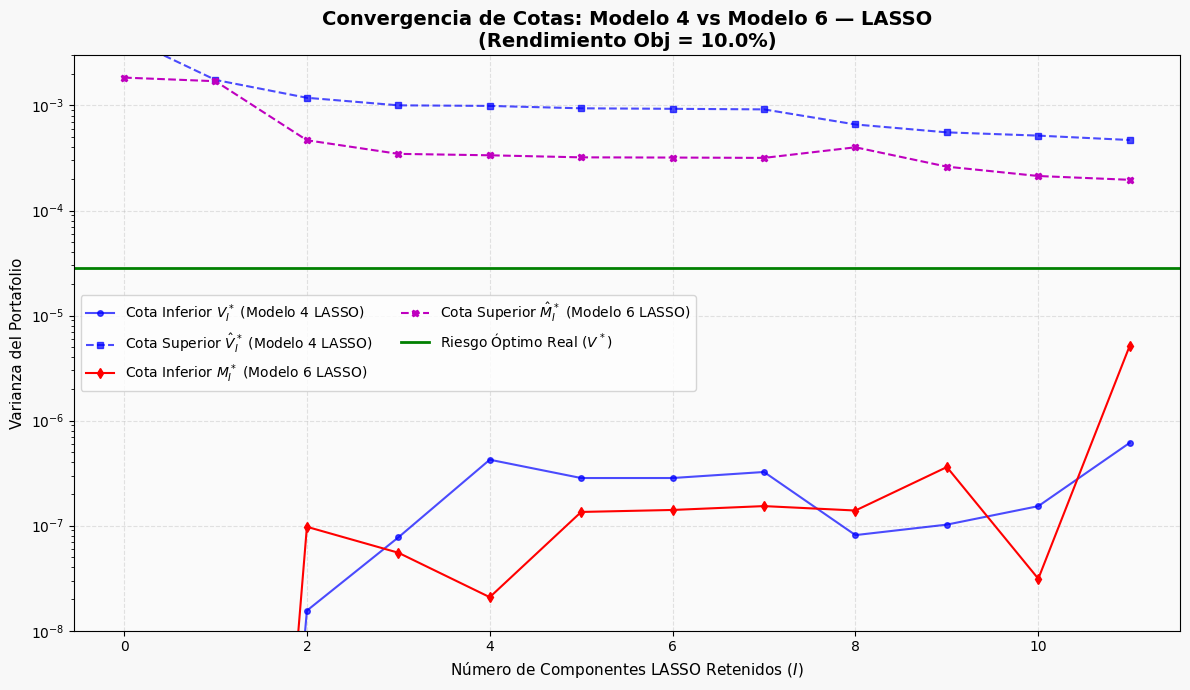

In [60]:
# MISMO ALPHA EN TODAS

cotas_inf_lasso    = []
cotas_sup_lasso    = []
cotas_inf_lasso_m6 = []
cotas_sup_lasso_m6 = []

for i in range(12):#rango_componentes:
    print(idx_lasso[:i])
    # LASSO: Modelo 4
    pesos_lasso, v_i_star_lasso = modelo_4_lasso(
        mu=mu_array, mu_P=mu_P,
        eigenvalores=eigenvalues,
        eigenvectores=eigenvectors,
        idx_componentes=idx_lasso[:i])

    # LASSO: Modelo 6
    pesos_lasso_m6, m_i_star_lasso = modelo_6_lasso(
        mu=mu_array, mu_P=mu_P,
        eigenvalues=eigenvalues,
        eigenvectors=eigenvectors,
        idx_componentes=idx_lasso[:i],
        Sigma=sigma_array,
        x_bar=pesos_lasso)

    cotas_inf_lasso.append(v_i_star_lasso)
    cotas_sup_lasso.append(pesos_lasso.T @ sigma_array @ pesos_lasso)
    cotas_inf_lasso_m6.append(m_i_star_lasso)
    cotas_sup_lasso_m6.append(pesos_lasso_m6.T @ sigma_array @ pesos_lasso_m6)

# Grafica
fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor('#f8f8f8')
ax.set_facecolor('#fafafa')
ax.grid(True, linestyle='--', alpha=0.35)

ax.plot(list(range(12)), cotas_inf_lasso,    'b-o',  markersize=4, alpha=0.7,
        label=r'Cota Inferior $V_I^*$ (Modelo 4 LASSO)')
ax.plot(list(range(12)), cotas_sup_lasso,    'b--s', markersize=4, alpha=0.7,
        label=r'Cota Superior $\hat{V}_I^*$ (Modelo 4 LASSO)')
ax.plot(list(range(12)), cotas_inf_lasso_m6, 'r-d',  markersize=5,
        label=r'Cota Inferior $M_I^*$ (Modelo 6 LASSO)')
ax.plot(list(range(12)), cotas_sup_lasso_m6, 'm--X', markersize=5,
        label=r'Cota Superior $\hat{M}_I^*$ (Modelo 6 LASSO)')

ax.axhline(y=V_optimo, color='g', linestyle='-', linewidth=2,
           label=r'Riesgo Óptimo Real ($V^*$)')

ax.set_title(f'Convergencia de Cotas: Modelo 4 vs Modelo 6 — LASSO\n'
             f'(Rendimiento Obj = {mu_P*100:.1f}%)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Número de Componentes LASSO Retenidos ($I$)', fontsize=11)
ax.set_ylabel('Varianza del Portafolio', fontsize=11)
ax.set_yscale('log')
ax.set_ylim([1e-8, 0.003])
ax.legend(loc='best', fontsize=10, ncol=2)

plt.tight_layout()
plt.show()

**Lasso preserva el comportamiento de ambos modelos.**

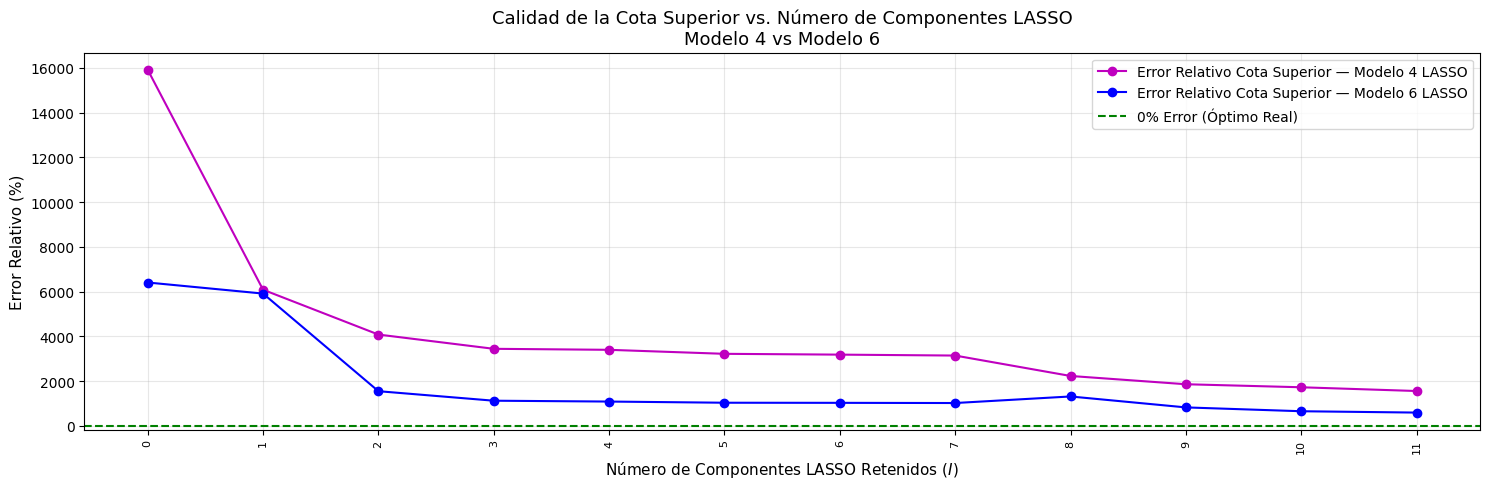

                                                Modelo 4   Modelo 6
----------------------------------------------------------------------
Error máximo usando 1 componente:               15919.36%    6408.20%
Error usando 12 componentes:                 1556.75661%  592.52207%


In [61]:
# Error Relativo : Calidad de la Cota Superior — Modelo 4 vs Modelo 6 (LASSO)

calidad_cota_superior_lasso_m4 = [((cota_sup - V_optimo) / V_optimo) * 100
                                   for cota_sup in cotas_sup_lasso]

calidad_cota_superior_lasso_m6 = [((cota_sup - V_optimo) / V_optimo) * 100
                                   for cota_sup in cotas_sup_lasso_m6]

plt.figure(figsize=(15, 5))
fig.patch.set_facecolor('#f8f8f8')

plt.plot(list(range(12)), calidad_cota_superior_lasso_m4, 'm-o',
         label='Error Relativo Cota Superior — Modelo 4 LASSO', markersize=6)
plt.plot(list(range(12)), calidad_cota_superior_lasso_m6, 'b-o',
         label='Error Relativo Cota Superior — Modelo 6 LASSO', markersize=6)

plt.axhline(0, color='green', linestyle='--', linewidth=1.5,
            label='0% Error (Óptimo Real)')

plt.title('Calidad de la Cota Superior vs. Número de Componentes LASSO\n'
          'Modelo 4 vs Modelo 6', fontsize=13)
plt.xlabel('Número de Componentes LASSO Retenidos ($I$)', fontsize=11)
plt.ylabel('Error Relativo (%)', fontsize=11)
plt.xticks(list(range(12)), rotation=90, fontsize=8)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Resumen
n = k_lasso
print(f"{'':45s} {'Modelo 4':>10} {'Modelo 6':>10}")
print("-" * 70)
print(f"Error máximo usando 1 componente:             "
      f"{calidad_cota_superior_lasso_m4[0]:>10.2f}% "
      f"{calidad_cota_superior_lasso_m6[0]:>10.2f}%")
print(f"Error usando {n} componentes:                 "
      f"{calidad_cota_superior_lasso_m4[n-1]:>10.5f}% "
      f"{calidad_cota_superior_lasso_m6[n-1]:>10.5f}%")

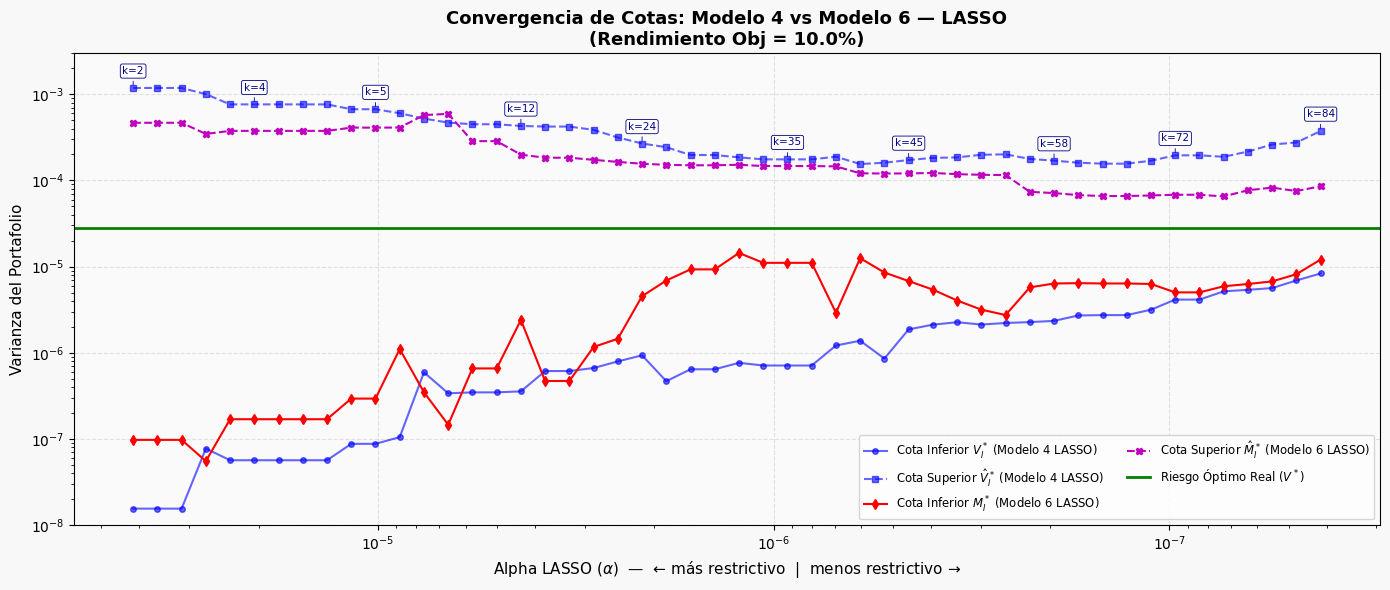

In [62]:
# Grid de alphas: de + restrictivo a -
alphas_grid = np.logspace(
    np.log10(lasso_cv.alpha_ * 10),   # alpha grande → pocos componentes
    np.log10(lasso_cv.alpha_ * 0.01), # alpha chico  → más componentes
    50)

cotas_inf_lasso = []
cotas_sup_lasso = []
cotas_inf_m6_lasso = []
cotas_sup_m6_lasso = []
n_componentes_lasso = []

for alpha in alphas_grid:
    # Selección de componentes con este alpha
    lasso_tmp = Lasso(alpha=alpha, fit_intercept=True, max_iter=10_000)
    lasso_tmp.fit(Z_hist, y_hist)

    mask_tmp = np.abs(lasso_tmp.coef_) > 1e-10
    idx_tmp  = np.where(mask_tmp)[0]
    # print(idx_tmp)
    k_tmp    = mask_tmp.sum()

    if k_tmp == 0:
        continue   # skip si anuló todo

    # Modelo 4 LASSO
    pesos_m4_tmp, v_tmp = modelo_4_lasso(
        mu=mu_array, mu_P=mu_P,
        eigenvalores=eigenvalues, eigenvectores=eigenvectors,
        idx_componentes=idx_tmp)

    # Modelo 6 LASSO
    pesos_m6_tmp, m_tmp = modelo_6_lasso(
        mu=mu_array, mu_P=mu_P,
        eigenvalues=eigenvalues, eigenvectors=eigenvectors,
        idx_componentes=idx_tmp,
        Sigma=sigma_array,
        x_bar=pesos_m4_tmp)

    cotas_inf_lasso.append(v_tmp)
    cotas_sup_lasso.append(pesos_m4_tmp.T @ sigma_array @ pesos_m4_tmp)
    cotas_inf_m6_lasso.append(m_tmp)
    cotas_sup_m6_lasso.append(pesos_m6_tmp.T @ sigma_array @ pesos_m6_tmp)
    n_componentes_lasso.append(k_tmp)

# Grafica, eje X = alpha
fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('#f8f8f8')
ax.set_facecolor('#fafafa')
ax.grid(True, linestyle='--', alpha=0.35)

ax.plot(alphas_grid[:len(cotas_inf_lasso)], cotas_inf_lasso,    'b-o',  markersize=4, alpha=0.6,
        label=r'Cota Inferior $V_I^*$ (Modelo 4 LASSO)')
ax.plot(alphas_grid[:len(cotas_sup_lasso)], cotas_sup_lasso,    'b--s', markersize=4, alpha=0.6,
        label=r'Cota Superior $\hat{V}_I^*$ (Modelo 4 LASSO)')
ax.plot(alphas_grid[:len(cotas_inf_m6_lasso)], cotas_inf_m6_lasso, 'r-d', markersize=5,
        label=r'Cota Inferior $M_I^*$ (Modelo 6 LASSO)')
ax.plot(alphas_grid[:len(cotas_sup_m6_lasso)], cotas_sup_m6_lasso, 'm--X', markersize=5,
        label=r'Cota Superior $\hat{M}_I^*$ (Modelo 6 LASSO)')
ax.axhline(y=V_optimo, color='g', linewidth=2, label=r'Riesgo Óptimo Real ($V^*$)')

n_anotaciones = 10
indices_anotar = np.linspace(0, len(n_componentes_lasso) - 1, n_anotaciones, dtype=int)

for i in indices_anotar:
    ax.annotate(f'k={n_componentes_lasso[i]}',
                xy=(alphas_grid[i], cotas_sup_lasso[i]),
                xytext=(0, 10), textcoords='offset points',
                fontsize=7.5, color='navy', ha='center',
                bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='navy', lw=0.6),
                arrowprops=dict(arrowstyle='-', color='navy', lw=0.6))

ax.set_xscale('log')
ax.invert_xaxis()
ax.set_xlabel(r'Alpha LASSO ($\alpha$)  —  ← más restrictivo  |  menos restrictivo →',
              fontsize=11)
ax.set_ylabel('Varianza del Portafolio', fontsize=11)
ax.set_yscale('log')
ax.set_ylim([1e-8, 0.003])
ax.set_title(f'Convergencia de Cotas: Modelo 4 vs Modelo 6 — LASSO\n'
             f'(Rendimiento Obj = {mu_P*100:.1f}%)', fontsize=13, fontweight='bold')
ax.legend(fontsize='small', ncol=2)

plt.tight_layout()
plt.show()

#### Aumenta y se preserva un poco del error relativo en ambos modelos.

## Frontera Eficiente

In [63]:
# print(k)

In [64]:
pesos_m4_graf, var_est_m4_lasso = modelo_4_lasso(
    mu=mu_array, mu_P=mu_P,
    eigenvalores=eigenvalues, eigenvectores=eigenvectors,
    idx_componentes=idx_lasso)

var_real_m4_lasso = pesos_m4_graf.T @ sigma_array @ pesos_m4_graf

pesos_m6_graf, var_est_m6_lasso = modelo_6_lasso(
    mu=mu_array, mu_P=mu_P,
    eigenvalues=eigenvalues, eigenvectors=eigenvectors,
    idx_componentes=idx_lasso,
    Sigma=sigma_array,
    x_bar=pesos_m4_graf)

var_real_m6_lasso = pesos_m6_graf.T @ sigma_array @ pesos_m6_graf

std_est_m4_lasso  = np.sqrt(var_est_m4_lasso)
std_real_m4_lasso = np.sqrt(var_real_m4_lasso)
vol_est_m6_lasso  = np.sqrt(var_est_m6_lasso)
vol_real_m6_lasso = np.sqrt(var_real_m6_lasso)

vol_activos = np.sqrt(np.diag(sigma_array))

fig = go.Figure()
# volvemos a calcular std_eigen pero para las 122 acciones

Z_full = rendimientos_log.values @ eigenvectors

var_eigen = np.array([
    eigenvectors[:, i].T @ sigma_array @ eigenvectors[:, i]
    for i in range(len(eigenvalues))   # itera sobre los 122
])
std_eigen = np.sqrt(var_eigen)

# Rendimiento esperado de cada eigenportafolio
ren_eigen = np.array([
    mu_array @ eigenvectors[:, i]
    for i in range(len(eigenvalues))
])

# Activos individuales
fig.add_trace(go.Scatter(
    x=vol_activos, y=mu_array,
    mode='markers',
    marker=dict(color='lightgray', size=5, opacity=0.5,
                line=dict(color='gray', width=0.3)),
    name='Activos individuales',
    hovertemplate='σ=%{x:.4f}<br>μ=%{y:.4f}<extra></extra>'))

# 20 Eigenportafolios PCA
k_mostrar = 20

fig.add_trace(go.Scatter(
    x=std_eigen[:k_mostrar],
    y=ren_eigen[:k_mostrar],
    mode='markers+text',
    marker=dict(color='royalblue', size=8, opacity=0.7,
                line=dict(color='navy', width=1)),
    text=[f'e{i+1}' for i in range(k_mostrar)],
    textposition='top right',
    textfont=dict(size=9, color='steelblue'),
    name=f'Eigenportafolios PCA (primeros {k_mostrar})',
    hovertext=[f'e{i+1}<br>σ={std_eigen[i]:.4f}<br>μ={ren_eigen[i]:.4f}'
               for i in range(k_mostrar)],
    hoverinfo='text'))

# Frontera completa
fig.add_trace(go.Scatter(
    x=sigma_full, y=r_full,
    mode='lines',
    line=dict(color='black', width=1, dash='dot'),
    opacity=0.35,
    name='Frontera completa',
    hoverinfo='skip'))

# Frontera eficiente
fig.add_trace(go.Scatter(
    x=sigma_eff, y=r_eff,
    mode='lines',
    line=dict(color='black', width=2.5),
    name='Frontera Eficiente (Markowitz)',
    hovertemplate='σ=%{x:.4f}<br>μ=%{y:.4f}<extra>Frontera</extra>'))

# Linea de rendimiento objetivo
fig.add_hline(y=mu_P, line=dict(color='crimson', dash='dash', width=1.5),
              opacity=0.7,
              annotation_text=f'Objetivo {mu_P*100:.0f}%',
              annotation_position='right')

# Puntos especiales
puntos = {
    'IPC (Mercado)':          (std_index,        mu_index, 'green',       'star',     16),
    'Min. Var.':              (std_gmvp,         ren_gmvp, 'orange',      'diamond',  12),
    # PCA
    r'PCA M4 V̂_I*':         (std_est_m4,       mu_P,     'mediumblue',  'square',   12),
    r'PCA M4 V* real':        (std_real_m4,      mu_P,     'navy',        'circle',   12),
    r'PCA M6 M̂_I*':         (vol_est_m6,       mu_P,     'darkorchid',  'square',   12),
    r'PCA M6 M* real':        (vol_real_m6,      mu_P,     'purple',      'circle',   12),
    # LASSO
    r'LASSO M4 V̂_I*':       (std_est_m4_lasso, mu_P,     'deepskyblue', 'square',   12),
    r'LASSO M4 V* real':      (std_real_m4_lasso,mu_P,     'dodgerblue',  'circle',   12),
    r'LASSO M6 M̂_I*':       (vol_est_m6_lasso, mu_P,     'hotpink',     'square',   12),
    r'LASSO M6 M* real':      (vol_real_m6_lasso,mu_P,     'deeppink',    'circle',   12),
}

for label, (vx, ry, col, sym, sz) in puntos.items():
    fig.add_trace(go.Scatter(
        x=[vx], y=[ry],
        mode='markers+text',
        marker=dict(color=col, symbol=sym, size=sz,
                    line=dict(color='white', width=1)),
        text=[label],
        textposition='top right',
        textfont=dict(size=10, color=col),
        name=label,
        hovertemplate=f'<b>{label}</b><br>σ=%{{x:.5f}}<br>μ=%{{y:.4f}}<extra></extra>'))


all_stds = [std_est_m4, std_real_m4, vol_est_m6, vol_real_m6,
            std_est_m4_lasso, std_real_m4_lasso,
            vol_est_m6_lasso, vol_real_m6_lasso]
x_max = max(np.nanpercentile(np.concatenate([std_eigen[:k_mostrar], vol_activos]), 95),
            *all_stds) * 1.3

fig.update_layout(
    title=dict(
        text=(f'Modelos 4 y 6 (PCA k={k} vs LASSO k={k_lasso}) '
              f'vs Frontera Eficiente'),
        font=dict(size=16, color='#222'),
        x=0.5),
    xaxis=dict(
        title='Volatilidad (σ)',
        range=[-x_max * 0.04, x_max],
        gridcolor='#ebebeb', gridwidth=1,
        zeroline=True, zerolinecolor='#aaa', zerolinewidth=1),
    yaxis=dict(
        title='Rendimiento esperado (μ)',
        range=[mu_array.min() * 1.15, mu_array.max() * 1.1],
        gridcolor='#ebebeb', gridwidth=1),
    legend=dict(
        x=0.01, y=0.99,
        bgcolor='rgba(255,255,255,0.85)',
        bordercolor='#ccc', borderwidth=1,
        font=dict(size=10),orientation='h'),
    plot_bgcolor='white',
    paper_bgcolor='white',
    width=1150, height=720,
    hovermode='closest')

fig.show()

**El desempeño entre PCA y Lasso no se diferencia mucho, es decir terminan siendo muy similares.**

## Ponderaciones en los portafolios

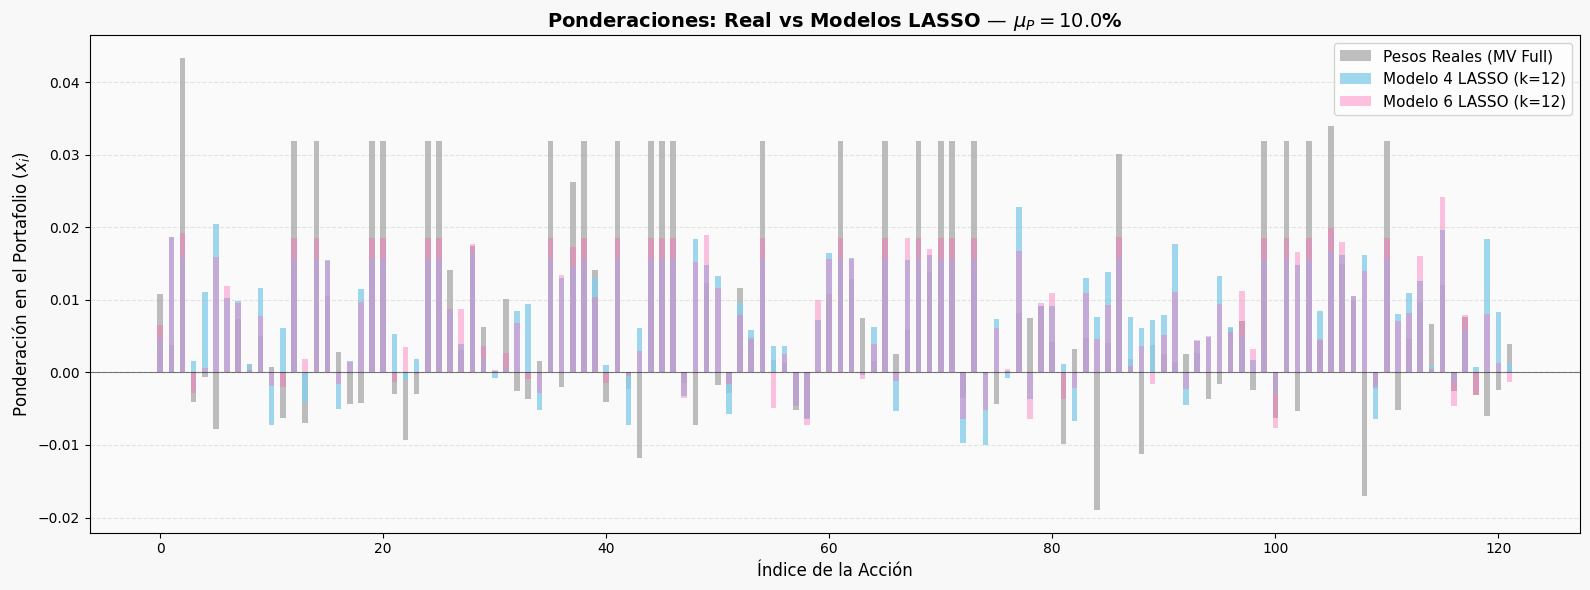

In [65]:
fig, ax = plt.subplots(figsize=(16, 6))
fig.patch.set_facecolor('#f8f8f8')
ax.set_facecolor('#fafafa')

x = np.arange(len(pesos_optimos_orig))
ancho = 0.5

ax.bar(x, pesos_optimos_orig,
       width=ancho, alpha=0.5, color='gray',
       label='Pesos Reales (MV Full)')
ax.bar(x,         pesos_lasso,
       width=ancho, alpha=0.8, color='skyblue',
       label=f'Modelo 4 LASSO (k={k_lasso})')
ax.bar(x, pesos_lasso_m6,
       width=ancho, alpha=0.4, color='hotpink',
       label=f'Modelo 6 LASSO (k={k_lasso})')

ax.axhline(0, color='black', linewidth=0.8, alpha=0.5)
ax.set_xlabel('Índice de la Acción', fontsize=12)
ax.set_ylabel('Ponderación en el Portafolio ($x_i$)', fontsize=12)
ax.set_title(
    fr'Ponderaciones: Real vs Modelos LASSO — $\mu_P = {mu_P*100:.1f}$%',
    fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# **Conclusiones:**


- El artículo demuestra que no necesitamos analizar cada pequeño detalle de cada acción para construir un buen portafolio. Usando  PCA o Lasso y un ajuste de error, podemos obtener resultados fieles a la realidad de forma mucho más rápida y con menos complicaciones o riesgos en los cálculos con muchos datos.

- Incluir el error linealizado aumenta significativamente la precisión de la estimación de ponderaciones óptimas dado un rendimiento esperado determinado.

- Tenemos la ventaja de que no usamos las 123 acciones originales para obtener una buena aproximación de un portafolio de mínima varianza.

- Nuestro problema se reduce a la selección de factores (eigenportfolios) y sus respectivos riesgos para la ponderación de activos.

- RECUERDEN: ¡SI PODEMOS aproximar el portafolio de mínima varianza con un error minimo dependiendo de la cantidad de información que deseemos incluir en el modelo!

- Como estos modelos existen más pero esta presentación solo se abordan estos 2.

- Al final sí pudimos obtener un método óptimo que nos permite **ganar dinero**.

- Computacionalmente este método de optimización puede llegar a ser usualmente más eficiente.



# **Referencias:**

- Mayambala, F., Rönnberg, E., y Larsson, T. (2022). Eigendecomposition of the mean-variance portfolio optimization model. En A. Chinchuluun, P. M. Pardalos, y R. Enkhbat (Eds.), Optimization, control, and applications in the information age (pp. 209–232). Springer. https://doi.org/10.1007/978-3-030-99450-1_11

- Virtanen, P., Gommers, R., Oliphant, T. E., Haberland, M., Reddy, T., Cournapeau, D., Burovski, E., Peterson, P., Weckesser, W., Bright, J., van der Walt, S. J., Brett, M., Wilson, J., Millman, K. J., Mayorov, N., Nelson, A. R. J., Jones, E., Kern, R., Larson, E., ... SciPy 1.0 Contributors. (s.f.). scipy.optimize.minimize. SciPy Documentation. https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.minimize.html

- Walduin. O. (2025, 26 de marzo). Teoremas de la descomposición de valores propios en el modelo de media-varianza. RPubs. https://rpubs.com/owoc9103/1328591

- Wikipedia (2024). Teoría del portafolio moderna. Recuperado el 12 de abril de 2026 de https://es.wikipedia.org/wiki/Teoría_del_portafolio_moderna

# **Reporte autoría:**

- El preprocesamiento se basó en el notebook de Enrique.

- Ángel: Descomposición en valores propios y elección de primeros k componentes. Modificación de Modelos para transformación Q.

- Milena: Implementación Modelo 6. Implementación de Lasso. Modificaciones de los modelos para Lasso.

- Ignacio: Implementación Modelo 4. Introducción y  explicaciones. Conclusiones. Creación de material de apoyo.